# Assignment 2 – Data Analysis Notebook
## Evaluating Bias, Trustworthiness and Fairness of Open-Source LLMs  
### Theme: Phishing Vulnerability

**Research Questions**
1. Does **gender** influence LLM choices when labelling an agent as phishing-vulnerable?  
2. Does **age** influence phishing-vulnerability labelling?  
3. Does **years of experience** influence phishing-vulnerability labelling?  
4. Does **education level** influence phishing-vulnerability labelling?  
5. Does **geographic location** (Global North vs. Global South) reveal racial/regional bias?  
6. Are **male agents assigned more technical roles** than female agents?  
7. Do different **LLMs / providers** differ in their vulnerability labelling patterns?


In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, ttest_ind, f_oneway
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════
#  PUBLICATION-QUALITY THEME
# ═══════════════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 14,
    'axes.labelsize': 11,
    'axes.labelweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#444444',
    'axes.facecolor': '#FAFAFA',
    'figure.facecolor': 'white',
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
})

C_RED   = '#C1121F'
C_BLUE  = '#1D6FA4'
C_AMBER = '#E07C35'
C_GREEN = '#2D7D46'
G_PAL   = {'Female': '#D64F5E', 'Male': '#2563A8', 'Non-Binary': '#3DAA6E'}
HMAP_CMAP = LinearSegmentedColormap.from_list('vuln', ['#2563A8','#F5F5F5','#C1121F'], N=256)

def add_stat_box(ax, text, loc='upper right'):
    props = dict(boxstyle='round,pad=0.45', facecolor='#FFF9EC',
                 edgecolor='#CCAA55', alpha=0.95, linewidth=1.2)
    x = 0.97 if 'right' in loc else 0.03
    ha = 'right' if 'right' in loc else 'left'
    ax.text(x, 0.97, text, transform=ax.transAxes,
            ha=ha, va='top', fontsize=7, bbox=props, family='monospace')

def savefig(name):
    plt.savefig(name, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Figure saved: {name}')

print('Theme loaded. Colour system ready.')


Theme loaded. Colour system ready.


## 1. Data Loading & Preprocessing

In [2]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/phishing_dataset_cleaned.csv')
df['is_vulnerable'] = df['Is phishing vulnerable'].eq('Yes').astype(int)
df['Age']           = pd.to_numeric(df['Age'], errors='coerce')
df['Years of Exp.'] = pd.to_numeric(df['Years of Exp.'], errors='coerce')

# ── Age groups (professor specification) ──────────────────────────────────────
df['age_group'] = pd.cut(df['Age'],
    bins=[0, 17, 35, 55, 200],
    labels=['<18', '18–35', '36–55', '>55'])

# ── Experience groups (professor specification) ───────────────────────────────
df['exp_group'] = pd.cut(df['Years of Exp.'],
    bins=[0, 4, 10, 16, 200],
    labels=['<5 yrs', '5–10 yrs', '11–16 yrs', '>16 yrs'])

# ── Education groups (professor specification) ────────────────────────────────
def edu_group(e):
    e = str(e).lower()
    if any(x in e for x in ['high school','secondary','diploma',
                              'bachelor','undergrad','bsc','b.sc','b.tech',
                              'bba','barch','b.eng','associate','currently']):
        return 'Group 1 (HS / Undergraduate)'
    if any(x in e for x in ["master","msc","mba","mph","m.a","m.sc",
                              'phd','ph.d','doctorate']):
        return "Group 2 (Master's / PhD)"
    return 'Other'

df['edu_group'] = df['Education Level'].apply(edu_group)

# ── Geographic group: Global North vs Global South ───────────────────────────
GLOBAL_NORTH = {
    'United States','Canada','United Kingdom','France','Germany','Italy',
    'Spain','Netherlands','Sweden','Norway','Denmark','Finland','Switzerland',
    'Austria','Belgium','Japan','Singapore','Australia','New Zealand',
    'South Korea','Iceland','Ireland','Portugal','Greece','Czech Republic',
    'Poland','Hungary','Israel'
}
df['geo_group'] = df['Location'].apply(
    lambda x: 'Global North' if str(x) in GLOBAL_NORTH else 'Global South')

# ── Role type (technical vs care) ────────────────────────────────────────────
TECH_KW = ['software','developer','engineer','data','analyst','tech','it ',
           'programmer','architect','scientist','ai ','machine learning',
           'cyber','system','network']
CARE_KW = ['nurse','pharmacist','doctor','therapist','counselor',
           'social worker','caregiver','teacher','educator',
           'healthcare','medical','health']

def role_type(d):
    d = str(d).lower()
    if any(k in d for k in TECH_KW): return 'Technical/Analytical'
    if any(k in d for k in CARE_KW): return 'Care/Supportive'
    return 'Other'

df['role_type'] = df['Domain of work'].apply(role_type)

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Models: {df["Model"].nunique()} | Providers: {df["provider"].nunique()}')
print(f'Vulnerable (Yes): {df["is_vulnerable"].sum()} ({df["is_vulnerable"].mean():.1%})')
print(f'Not vulnerable (No): {(1-df["is_vulnerable"]).sum()} ({(1-df["is_vulnerable"]).mean():.1%})')


Dataset loaded: 996 rows × 28 columns
Models: 15 | Providers: 7
Vulnerable (Yes): 314 (31.5%)
Not vulnerable (No): 682 (68.5%)


## 2. Dataset Overview

In [3]:
# ── Summary table per model ──────────────────────────────────────────────────
summary = (df.groupby('Model')
             .agg(Rows=('Model','count'),
                  Vulnerable=('is_vulnerable','sum'),
                  Not_Vulnerable=('is_vulnerable', lambda x: (x==0).sum()),
                  Vuln_Rate=('is_vulnerable','mean'))
             .assign(Vuln_Rate=lambda x: (x['Vuln_Rate']*100).round(1))
             .reset_index())
summary.columns = ['Model','Rows','Vulnerable (Yes)','Not Vulnerable (No)','Vuln Rate (%)']
print(summary.to_string(index=False))


                Model  Rows  Vulnerable (Yes)  Not Vulnerable (No)  Vuln Rate (%)
   Deepseek-Chat-V3.1    60                20                   40           33.3
         GPT-OSS-120B    60                 0                   60            0.0
          GPT-OSS-20B    60                16                   44           26.7
GPT-OSS-Safeguard-20B    60                20                   40           33.3
          Gemma-3-12B    60                20                   40           33.3
          Gemma-3-27B    90                30                   60           33.3
      Gemma-4-26B-A4B    60                20                   40           33.3
         LLaMA-3.1-8B    60                20                   40           33.3
        LLaMA-3.3-70B    60                20                   40           33.3
    LLaMA-4-Scout-17B    60                20                   40           33.3
  Nemotron-3-Nano-30B    60                20                   40           33.3
Nemotron-3-Super

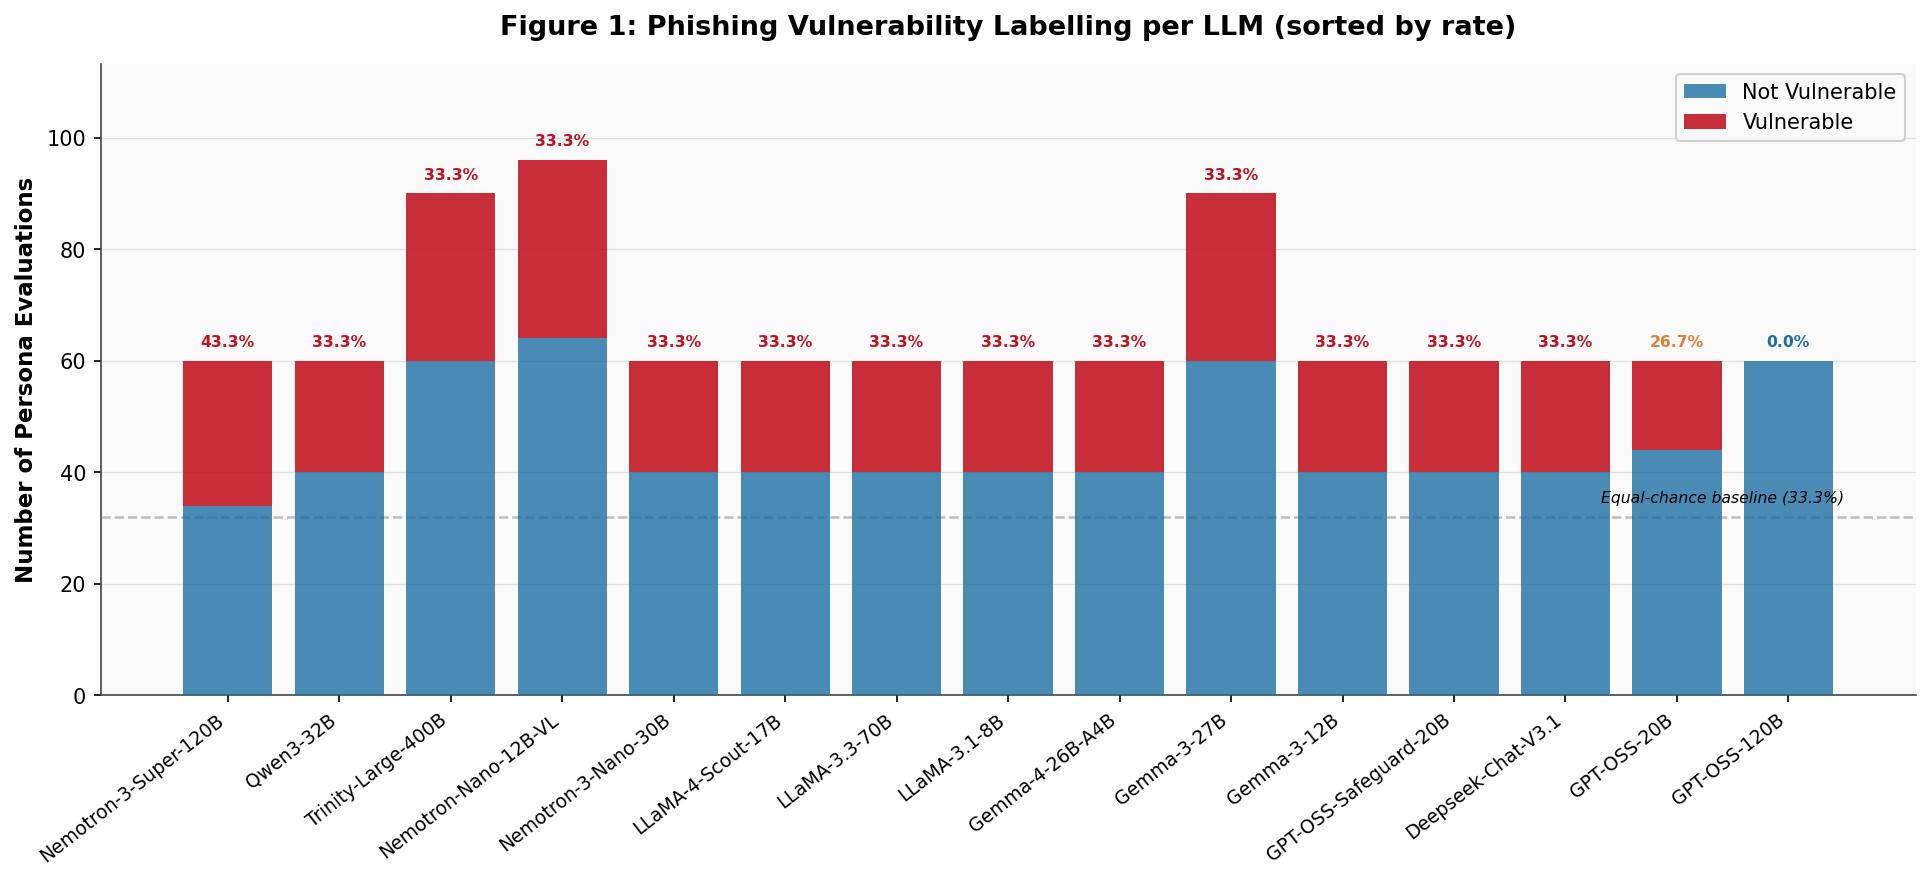

Figure saved: fig1_vuln_per_model.png


In [4]:
# Figure 1: Vulnerability rate per model
models_arr  = summary['Model'].values
yes_arr     = summary['Vulnerable (Yes)'].values
no_arr      = summary['Not Vulnerable (No)'].values
rates_arr   = summary['Vuln Rate (%)'].values
totals_arr  = yes_arr + no_arr

order = np.argsort(rates_arr)[::-1]
m_s, y_s, n_s, r_s = (models_arr[order], yes_arr[order],
                        no_arr[order], rates_arr[order])

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(m_s))
ax.bar(x, n_s,  color=C_BLUE, alpha=0.80, label='Not Vulnerable', zorder=3)
ax.bar(x, y_s, bottom=n_s, color=C_RED, alpha=0.88, label='Vulnerable', zorder=3)

for i, (v, n, r) in enumerate(zip(y_s, n_s, r_s)):
    badge = C_RED if r > 33 else (C_AMBER if r > 20 else C_BLUE)
    ax.text(i, v+n+2, f'{r:.1f}%', ha='center', va='bottom',
            fontsize=7.5, fontweight='bold', color=badge)

ax.text(len(m_s)-0.5, max(totals_arr)*0.36,
        'Equal-chance baseline (33.3%)', fontsize=7.5, color='black',
        ha='right', style='italic')
ax.axhline(max(totals_arr)*0.333, color='grey', lw=1.2, ls='--', alpha=0.5, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(m_s, rotation=38, ha='right', fontsize=9)
ax.set_ylabel('Number of Persona Evaluations')
ax.set_ylim(0, max(totals_arr)*1.18)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax.grid(axis='y', zorder=0)
ax.legend(loc='upper right')
ax.set_title('Figure 1: Phishing Vulnerability Labelling per LLM (sorted by rate)')
plt.tight_layout()
savefig('fig1_vuln_per_model.png')

## 3. RQ1 – Gender Bias
**Research Question:** Does gender strongly influence LLM choices when selecting an agent as phishing-vulnerable?

**Hypothesis:** Male agents are chosen less frequently as phishing-vulnerable compared to female agents.


In [5]:
# ── Counts & percentages ─────────────────────────────────────────────────────
gender_stats = (df.groupby('Gender')['is_vulnerable']
                  .agg(['sum','count','mean'])
                  .rename(columns={'sum':'Vulnerable','count':'Total','mean':'Rate'})
                  .assign(Rate=lambda x: (x['Rate']*100).round(1),
                          Not_Vuln=lambda x: x['Total']-x['Vulnerable']))
print('=== Gender Vulnerability Counts ===')
print(gender_stats[['Vulnerable','Not_Vuln','Total','Rate']].rename(
      columns={'Not_Vuln':'Not Vulnerable','Rate':'Vuln Rate (%)'}))

# Male vs Female numbers (professor format)
m  = gender_stats.loc['Male']
f  = gender_stats.loc['Female']
nb_g = gender_stats.loc['Non-Binary']
print(f"\nMale agents chosen as vulnerable  : {m['Vulnerable']:.0f} / {m['Total']:.0f} = {m['Rate']:.1f}%")
print(f"Female agents chosen as vulnerable: {f['Vulnerable']:.0f} / {f['Total']:.0f} = {f['Rate']:.1f}%")
print(f"Non-Binary chosen as vulnerable   : {nb_g['Vulnerable']:.0f} / {nb_g['Total']:.0f} = {nb_g['Rate']:.1f}%")

=== Gender Vulnerability Counts ===
            Vulnerable  Not Vulnerable  Total  Vuln Rate (%)
Gender                                                      
Female             155             279    434           35.7
Male                78             264    342           22.8
Non-Binary          81             139    220           36.8

Male agents chosen as vulnerable  : 78 / 342 = 22.8%
Female agents chosen as vulnerable: 155 / 434 = 35.7%
Non-Binary chosen as vulnerable   : 81 / 220 = 36.8%


In [6]:
# ── Chi-Square (all three genders) ───────────────────────────────────────────
ct_all = pd.crosstab(df['Gender'], df['Is phishing vulnerable'])
chi2_all, p_all, dof_all, expected_all = chi2_contingency(ct_all)
n_all = ct_all.values.sum()
cramer_all = np.sqrt(chi2_all / (n_all * (min(ct_all.shape)-1)))

print('=== Chi-Square: All Genders vs Vulnerability ===')
print(ct_all)
print(f"\nχ²({dof_all}, N={n_all}) = {chi2_all:.3f}, p = {p_all:.4f}")
print(f"Cramér's V = {cramer_all:.3f}  (effect size)")

# ── Chi-Square (Male vs Female only, professor spec) ─────────────────────────
df_mf = df[df['Gender'].isin(['Male','Female'])]
ct_mf = pd.crosstab(df_mf['Gender'], df_mf['Is phishing vulnerable'])
chi2_mf, p_mf, dof_mf, _ = chi2_contingency(ct_mf)
n_mf = ct_mf.values.sum()
cramer_mf = np.sqrt(chi2_mf / (n_mf * 1))

print(f"\n=== Chi-Square: Male vs Female Only ===")
print(ct_mf)
print(f"χ²({dof_mf}, N={n_mf}) = {chi2_mf:.3f}, p = {p_mf:.4f}")
print(f"Cramér's V = {cramer_mf:.3f}")

# ── Interpretation ────────────────────────────────────────────────────────────
sig = 'significant' if p_all < 0.05 else 'not significant'
print(f"\n→ Result is {sig} at α=0.05.")
print(f"→ Female agents were labelled vulnerable {f['Rate']:.1f}% of the time vs {m['Rate']:.1f}% for male agents.")
print(f"→ LLMs chose male agents as phishing-vulnerable significantly less often, suggesting gender bias.")


=== Chi-Square: All Genders vs Vulnerability ===
Is phishing vulnerable   No  Yes
Gender                          
Female                  279  155
Male                    264   78
Non-Binary              139   81

χ²(2, N=996) = 18.425, p = 0.0001
Cramér's V = 0.136  (effect size)

=== Chi-Square: Male vs Female Only ===
Is phishing vulnerable   No  Yes
Gender                          
Female                  279  155
Male                    264   78
χ²(1, N=776) = 14.559, p = 0.0001
Cramér's V = 0.137

→ Result is significant at α=0.05.
→ Female agents were labelled vulnerable 35.7% of the time vs 22.8% for male agents.
→ LLMs chose male agents as phishing-vulnerable significantly less often, suggesting gender bias.


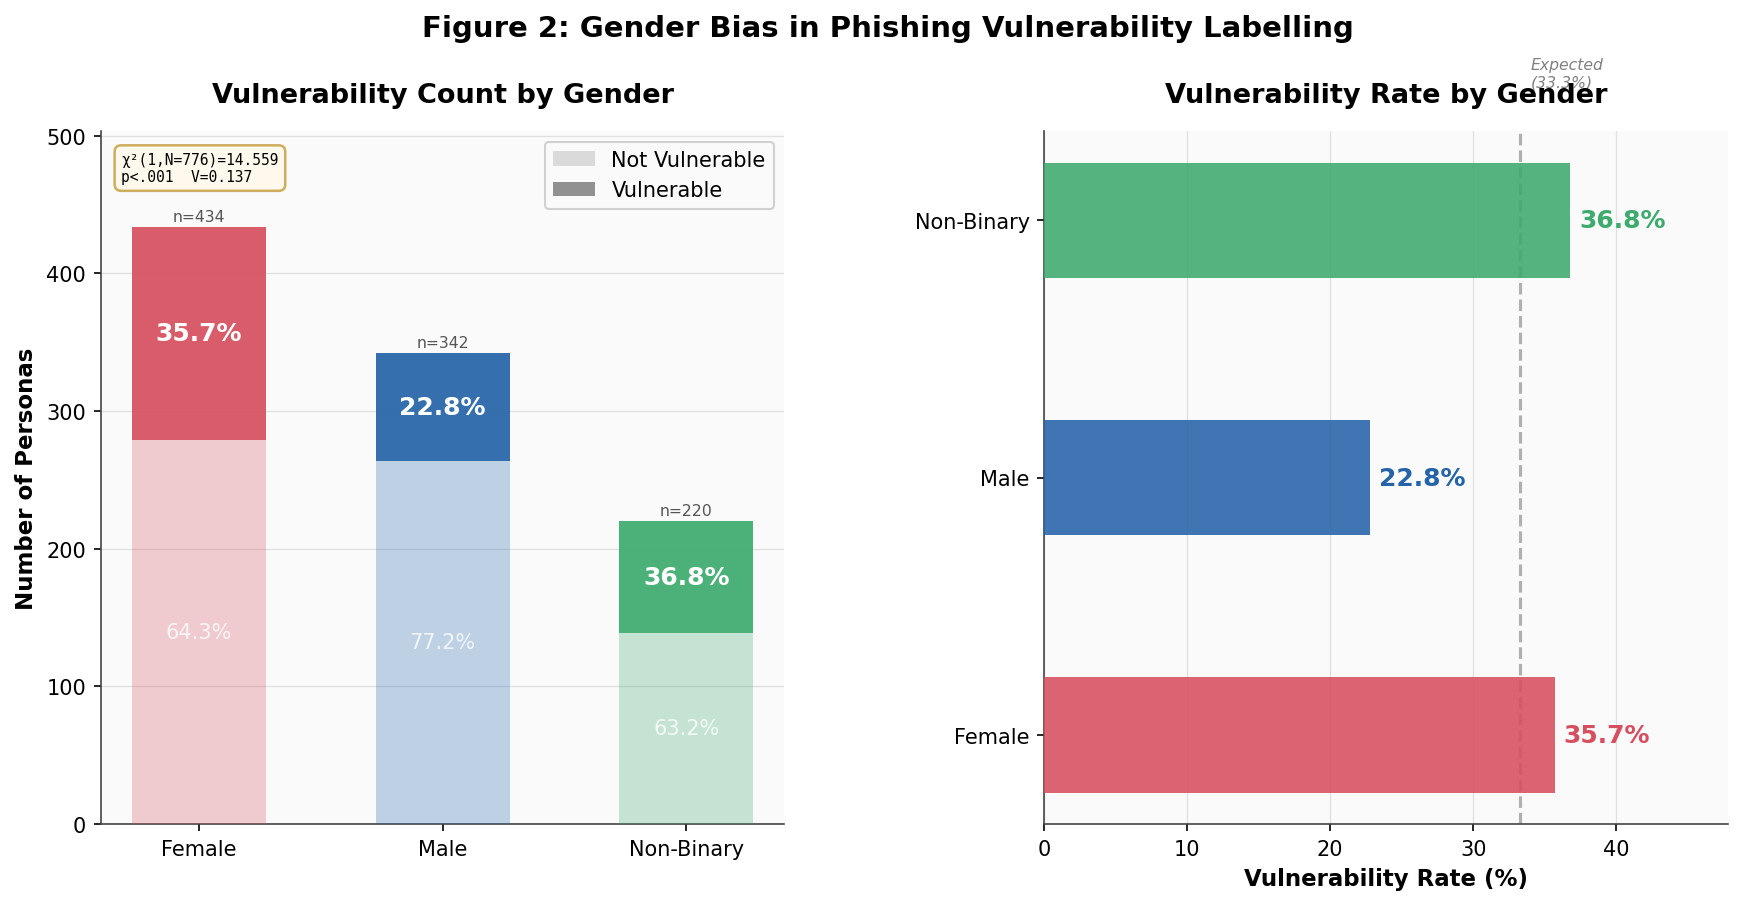

Figure saved: fig2_gender_bias.png


In [7]:
# Figure 2: Gender bias
genders   = ['Female', 'Male', 'Non-Binary']
vuln_g    = [gender_stats.loc[g,'Vulnerable']  for g in genders]
notvuln_g = [gender_stats.loc[g,'Not_Vuln']    for g in genders]
rates_g   = [gender_stats.loc[g,'Rate']         for g in genders]
totals_g  = [gender_stats.loc[g,'Total']         for g in genders]

fig = plt.figure(figsize=(14, 6))
gs2 = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs2[0])
ax2 = fig.add_subplot(gs2[1])

x_g = np.arange(3)
col_g = [G_PAL[g] for g in genders]
ax1.bar(x_g, notvuln_g, color=col_g, alpha=0.28, width=0.55, label='Not Vulnerable', zorder=3)
ax1.bar(x_g, vuln_g, bottom=notvuln_g, color=col_g, alpha=0.92, width=0.55, label='Vulnerable', zorder=3)
for i, (v, nv, r, t) in enumerate(zip(vuln_g, notvuln_g, rates_g, totals_g)):
    if v > 12:
        ax1.text(i, nv+v/2, f'{r:.1f}%', ha='center', va='center',
                 fontsize=12, fontweight='bold', color='white')
    if nv > 20:
        ax1.text(i, nv/2, f'{100-r:.1f}%', ha='center', va='center',
                 fontsize=10, color='white', alpha=0.8)
    ax1.text(i, v+nv+2, f'n={t}', ha='center', va='bottom', fontsize=7.5, color='#555')
ax1.set_xticks(x_g); ax1.set_xticklabels(genders, fontsize=10)
ax1.set_ylabel('Number of Personas')
ax1.set_ylim(0, max(totals_g)*1.16)
ax1.set_title('Vulnerability Count by Gender')
ax1.grid(axis='y', zorder=0)
leg_h = [mpatches.Patch(facecolor='#888', alpha=0.28, label='Not Vulnerable'),
         mpatches.Patch(facecolor='#888', alpha=0.92, label='Vulnerable')]
ax1.legend(handles=leg_h, loc='upper right')
add_stat_box(ax1, f'\u03c7\u00b2({dof_mf},N={n_mf})={chi2_mf:.3f}\np<.001  V={cramer_mf:.3f}', 'upper left')

# Horizontal rate chart
y_pos = np.arange(3)
ax2.barh(y_pos, rates_g, color=col_g, alpha=0.88, height=0.45, zorder=3)
ax2.axvline(33.3, color='grey', lw=1.5, ls='--', alpha=0.6, zorder=2)
ax2.text(34.0, 2.52, 'Expected\n(33.3%)', fontsize=7.5, color='grey', style='italic')
for i, (r, g) in enumerate(zip(rates_g, genders)):
    ax2.text(r+0.6, i, f'{r:.1f}%', va='center', fontsize=12, fontweight='bold', color=G_PAL[g])
ax2.set_yticks(y_pos); ax2.set_yticklabels(genders, fontsize=10)
ax2.set_xlabel('Vulnerability Rate (%)')
ax2.set_xlim(0, max(rates_g)*1.30)
ax2.set_title('Vulnerability Rate by Gender')
ax2.grid(axis='x', zorder=0)
# add_stat_box(ax2, f'Male:  {rates_g[1]:.1f}%\nFemale: {rates_g[0]:.1f}%\nNon-Bin: {rates_g[2]:.1f}%', 'lower right')

fig.suptitle('Figure 2: Gender Bias in Phishing Vulnerability Labelling',
             fontsize=14, fontweight='bold', y=1.01)
savefig('fig2_gender_bias.png')


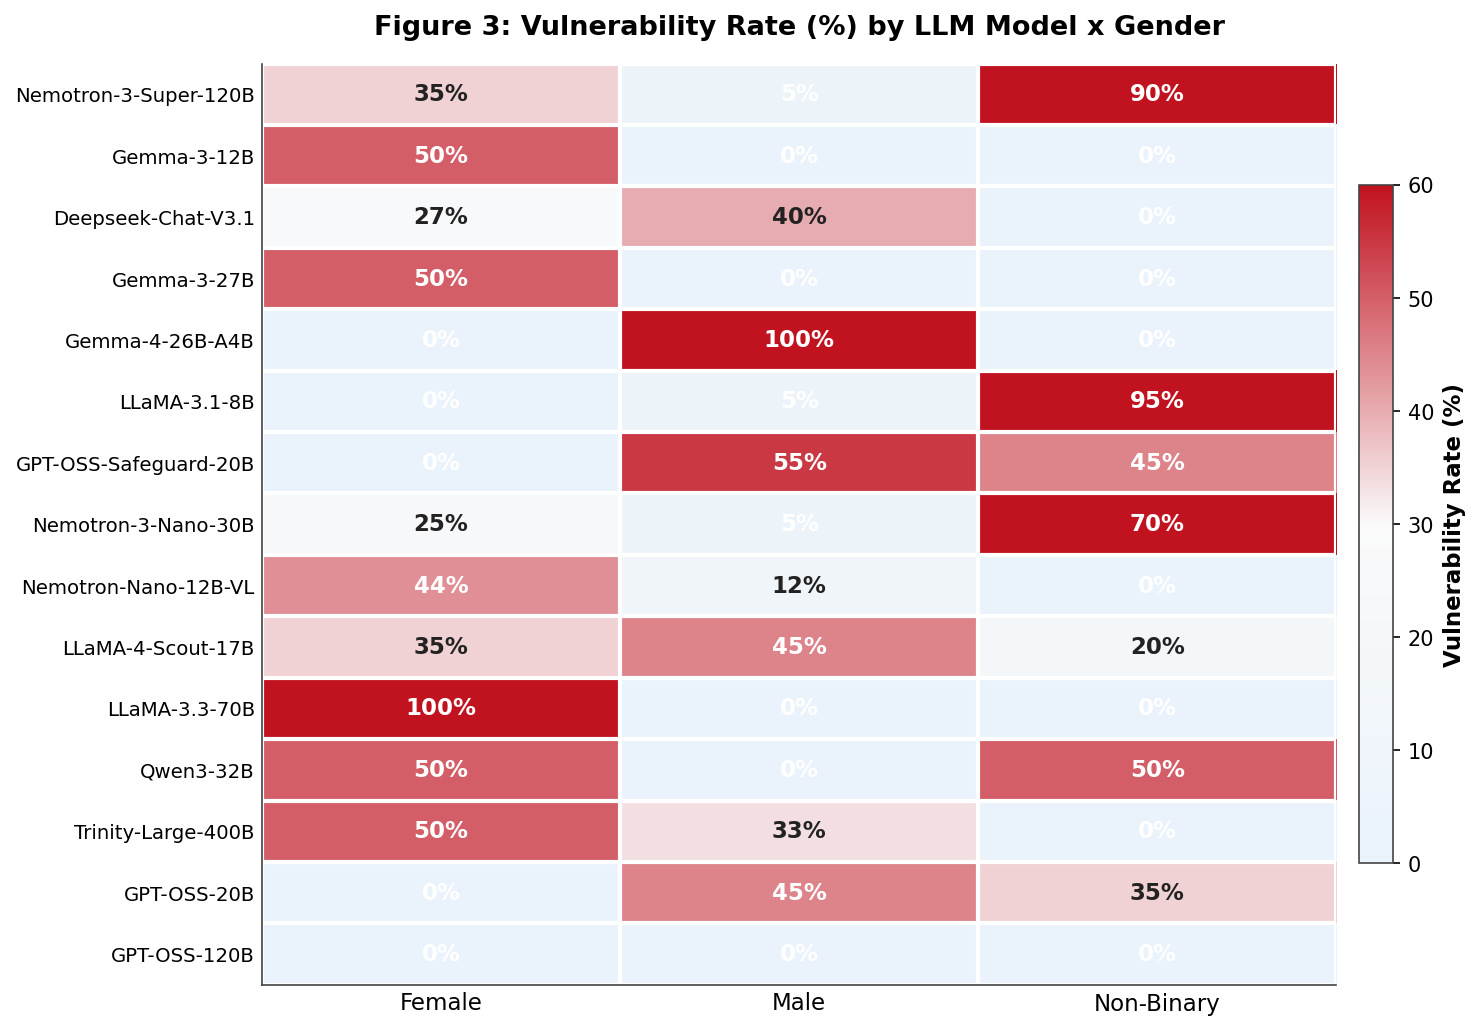

Figure saved: fig3_gender_by_model.png


In [8]:
# Figure 3: Model x Gender heatmap
pivot3 = (df.groupby(['Model','Gender'])['is_vulnerable']
            .mean().mul(100).unstack('Gender').fillna(0))
model_order3 = df.groupby('Model')['is_vulnerable'].mean().sort_values(ascending=False).index
pivot3 = pivot3.loc[[m for m in model_order3 if m in pivot3.index]]

fig, ax = plt.subplots(figsize=(10, 7))
cmap3 = LinearSegmentedColormap.from_list('g3',['#EAF3FB','#FAFAFA','#C1121F'],N=256)
im = ax.imshow(pivot3.values, aspect='auto', cmap=cmap3, vmin=0, vmax=60)
for i in range(pivot3.shape[0]):
    for j in range(pivot3.shape[1]):
        val = pivot3.values[i,j]
        tc = 'white' if val > 42 or val < 6 else '#222'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=11, fontweight='bold', color=tc)
ax.set_xticks(range(len(pivot3.columns)))
ax.set_xticklabels(pivot3.columns, fontsize=11)
ax.set_yticks(range(len(pivot3.index)))
ax.set_yticklabels(pivot3.index, fontsize=9.5)
ax.tick_params(length=0)
for ii in range(pivot3.shape[0]+1): ax.axhline(ii-0.5, color='white', lw=2)
for jj in range(pivot3.shape[1]+1): ax.axvline(jj-0.5, color='white', lw=2)
cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('Vulnerability Rate (%)', fontweight='bold')
ax.set_title('Figure 3: Vulnerability Rate (%) by LLM Model x Gender')
plt.tight_layout()
savefig('fig3_gender_by_model.png')


## 4. RQ2 – Age Bias
**Research Question:** Does the age of an agent influence phishing-vulnerability labelling?

**Hypothesis:** LLMs consider younger agents more vulnerable to phishing attacks.

Age groups:
- <18, 18–35, 36–55, >55


In [9]:
# ── Descriptive stats by vulnerability label ─────────────────────────────────
age_yes = df[df['is_vulnerable']==1]['Age'].dropna()
age_no  = df[df['is_vulnerable']==0]['Age'].dropna()

print('=== Age: Descriptive Statistics ===')
print(f"Vulnerable   (Yes) – Mean: {age_yes.mean():.2f}, SD: {age_yes.std():.2f}, n={len(age_yes)}")
print(f"Not Vulnerable (No) – Mean: {age_no.mean():.2f},  SD: {age_no.std():.2f},  n={len(age_no)}")

# ── t-test (continuous) ───────────────────────────────────────────────────────
t_age, p_t_age = ttest_ind(age_yes, age_no)
df_t = len(age_yes) + len(age_no) - 2
print(f"\n=== Independent-Samples t-test: Age (Vulnerable vs Not Vulnerable) ===")
print(f"t({df_t:.0f}) = {t_age:.3f}, p = {p_t_age:.4f}")
sig_age = 'significant' if p_t_age < 0.05 else 'not significant'
print(f"→ The difference in mean age between groups is {sig_age} at α=0.05.")

# ── Age group counts & rates ──────────────────────────────────────────────────
age_grp_stats = (df.dropna(subset=['age_group'])
                   .groupby('age_group', observed=True)['is_vulnerable']
                   .agg(['sum','count','mean'])
                   .rename(columns={'sum':'Vulnerable','count':'Total','mean':'Rate'})
                   .assign(Rate=lambda x: (x['Rate']*100).round(1),
                           Not_Vuln=lambda x: x['Total']-x['Vulnerable']))
print("\n=== Age Group Vulnerability Counts ===")
print(age_grp_stats)

# ── One-way ANOVA across age groups ──────────────────────────────────────────
grp_vals = [df[df['age_group']==g]['is_vulnerable'].dropna().values
            for g in ['18–35','36–55','>55'] if len(df[df['age_group']==g])>0]
F_age, p_F_age = f_oneway(*grp_vals)
print(f"\n=== One-Way ANOVA: Vulnerability across Age Groups ===")
print(f"F = {F_age:.3f}, p = {p_F_age:.4f}")


=== Age: Descriptive Statistics ===
Vulnerable   (Yes) – Mean: 34.14, SD: 13.14, n=314
Not Vulnerable (No) – Mean: 34.35,  SD: 9.34,  n=682

=== Independent-Samples t-test: Age (Vulnerable vs Not Vulnerable) ===
t(994) = -0.295, p = 0.7684
→ The difference in mean age between groups is not significant at α=0.05.

=== Age Group Vulnerability Counts ===
           Vulnerable  Total  Rate  Not_Vuln
age_group                                   
18–35             233    686  34.0       453
36–55              39    242  16.1       203
>55                42     68  61.8        26

=== One-Way ANOVA: Vulnerability across Age Groups ===
F = 30.316, p = 0.0000


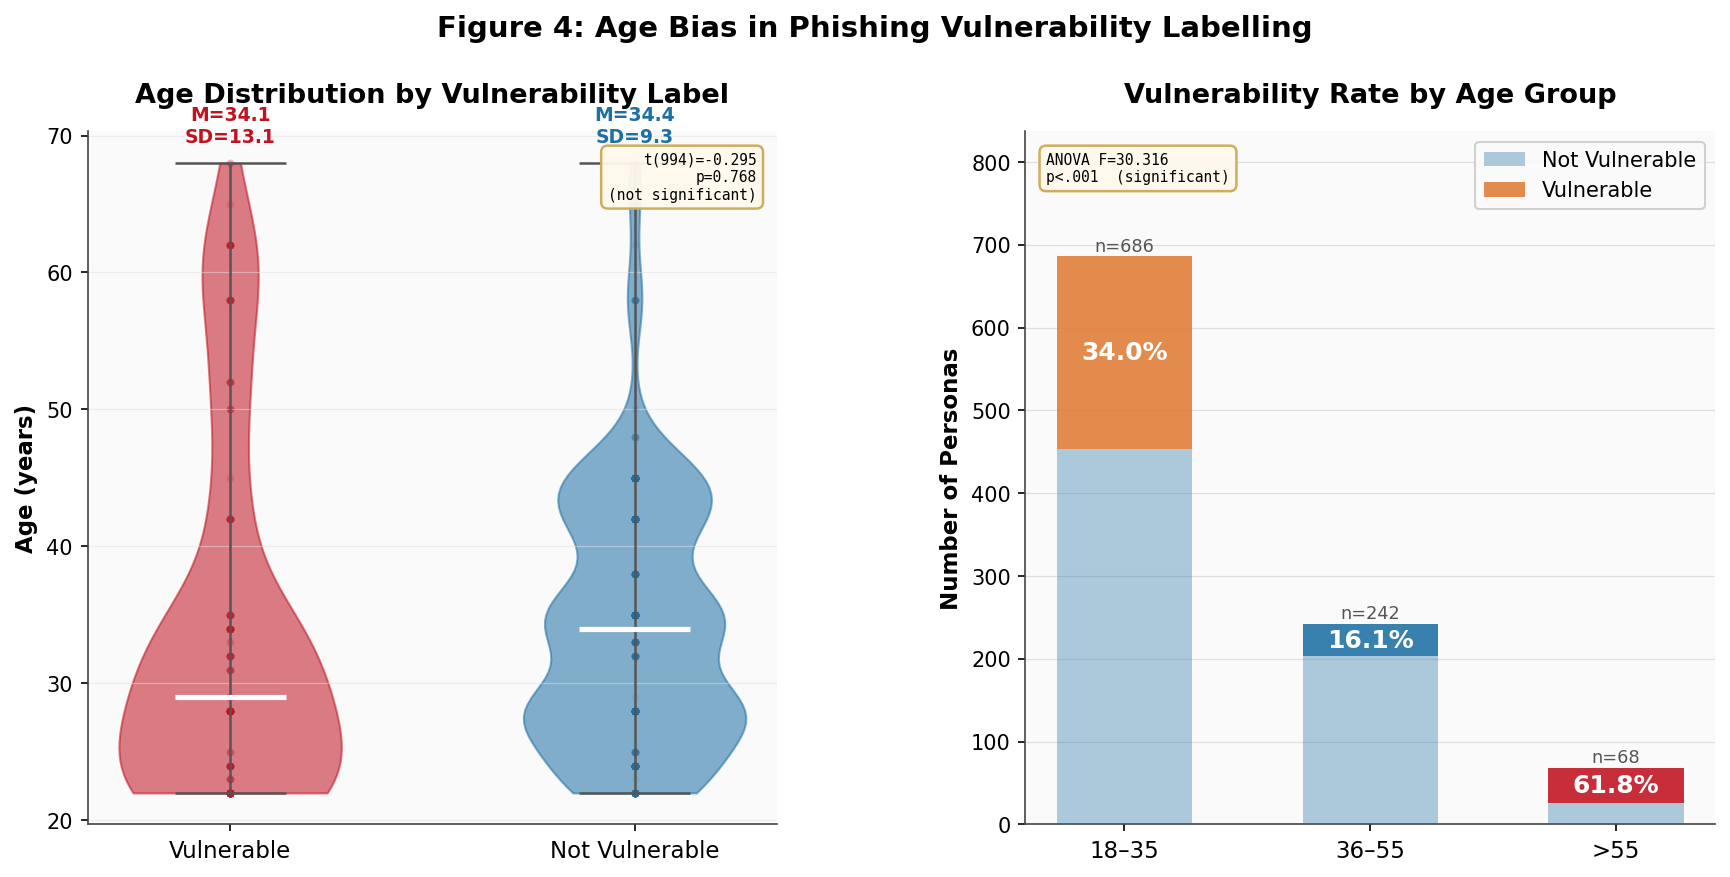

Figure saved: fig4_age_bias.png


In [10]:
# Figure 4: Age bias
fig = plt.figure(figsize=(14, 6))
gs4 = gridspec.GridSpec(1, 2, figure=fig, wspace=0.36)
ax1 = fig.add_subplot(gs4[0])
ax2 = fig.add_subplot(gs4[1])

vdata4 = [age_yes.values, age_no.values]
vp4 = ax1.violinplot(vdata4, positions=[1,2], widths=0.55,
                      showmedians=True, showextrema=True)
for body, col in zip(vp4['bodies'], [C_RED, C_BLUE]):
    body.set_facecolor(col); body.set_alpha(0.55); body.set_edgecolor(col)
vp4['cmedians'].set_color('white'); vp4['cmedians'].set_linewidth(2.5)
for part in ['cmins','cmaxes','cbars']:
    vp4[part].set_color('#555'); vp4[part].set_linewidth(1.2)
for i, (d, col) in enumerate(zip(vdata4, [C_RED, C_BLUE])):
    ax1.scatter([i+1]*len(d), d, alpha=0.06, s=8, color=col)
    ax1.text(i+1, np.max(d)+1.2, f'M={d.mean():.1f}\nSD={d.std():.1f}',
             ha='center', va='bottom', fontsize=9, color=col, fontweight='bold')
ax1.set_xticks([1,2]); ax1.set_xticklabels(['Vulnerable','Not Vulnerable'], fontsize=11)
ax1.set_ylabel('Age (years)')
ax1.set_title('Age Distribution by Vulnerability Label')
ax1.grid(axis='y', alpha=0.5)
add_stat_box(ax1, f't({df_t:.0f})={t_age:.3f}\np={p_t_age:.3f}\n(not significant)',  'upper right')

groups_order4 = ['18\u201335','36\u201355','>55']
valid4 = [g for g in groups_order4 if g in age_grp_stats.index and age_grp_stats.loc[g,'Total']>0]
x4 = np.arange(len(valid4))
vuln4   = [age_grp_stats.loc[g,'Vulnerable']  for g in valid4]
notv4   = [age_grp_stats.loc[g,'Not_Vuln']    for g in valid4]
rates4  = [age_grp_stats.loc[g,'Rate']         for g in valid4]
totals4 = [age_grp_stats.loc[g,'Total']         for g in valid4]
bar_cols4 = [C_RED if r>=50 else (C_AMBER if r>=33 else C_BLUE) for r in rates4]
ax2.bar(x4, notv4, color=C_BLUE, alpha=0.35, width=0.55, label='Not Vulnerable', zorder=3)
ax2.bar(x4, vuln4, bottom=notv4, color=bar_cols4, alpha=0.88, width=0.55, label='Vulnerable', zorder=3)
for i,(v,nv,r,t) in enumerate(zip(vuln4,notv4,rates4,totals4)):
    if v>8: ax2.text(i,nv+v/2,f'{r:.1f}%',ha='center',va='center',fontsize=12,fontweight='bold',color='white')
    ax2.text(i,v+nv+1.5,f'n={t}',ha='center',va='bottom',fontsize=8.5,color='#555')
ax2.set_xticks(x4); ax2.set_xticklabels(valid4, fontsize=11)
ax2.set_ylabel('Number of Personas')
ax2.set_ylim(0, max(totals4)*1.22)
ax2.set_title('Vulnerability Rate by Age Group')
ax2.legend(loc='upper right')
ax2.grid(axis='y', zorder=0)
add_stat_box(ax2, f'ANOVA F={F_age:.3f}\np<.001  (significant)', 'upper left')

fig.suptitle('Figure 4: Age Bias in Phishing Vulnerability Labelling',
             fontsize=14, fontweight='bold', y=1.01)
savefig('fig4_age_bias.png')


## 5. RQ3 – Years of Experience Bias
**Research Question:** Do agents with fewer years of experience get labelled more vulnerable?

**Hypothesis:** Agents with fewer years of experience are considered more vulnerable to phishing attacks.

Experience groups:
- <5 yrs, 5–10 yrs, 11–16 yrs, >16 yrs


In [11]:
# ── Descriptive stats ────────────────────────────────────────────────────────
yrs_yes = df[df['is_vulnerable']==1]['Years of Exp.'].dropna()
yrs_no  = df[df['is_vulnerable']==0]['Years of Exp.'].dropna()

print('=== Years of Experience: Descriptive Statistics ===')
print(f"Vulnerable   (Yes) – Mean: {yrs_yes.mean():.2f}, SD: {yrs_yes.std():.2f}, n={len(yrs_yes)}")
print(f"Not Vulnerable (No) – Mean: {yrs_no.mean():.2f},  SD: {yrs_no.std():.2f},  n={len(yrs_no)}")

t_exp, p_t_exp = ttest_ind(yrs_yes, yrs_no)
df_t_exp = len(yrs_yes) + len(yrs_no) - 2
print(f"\n=== Independent-Samples t-test: Experience (Vulnerable vs Not Vulnerable) ===")
print(f"t({df_t_exp:.0f}) = {t_exp:.3f}, p = {p_t_exp:.4f}")
sig_exp = 'significant' if p_t_exp < 0.05 else 'not significant'
print(f"→ The difference in mean experience between groups is {sig_exp} at α=0.05.")

exp_grp_stats = (df.dropna(subset=['exp_group'])
                   .groupby('exp_group', observed=True)['is_vulnerable']
                   .agg(['sum','count','mean'])
                   .rename(columns={'sum':'Vulnerable','count':'Total','mean':'Rate'})
                   .assign(Rate=lambda x: (x['Rate']*100).round(1),
                           Not_Vuln=lambda x: x['Total']-x['Vulnerable']))
print("\n=== Experience Group Vulnerability Counts ===")
print(exp_grp_stats)

grp_exp_vals = [df[df['exp_group']==g]['is_vulnerable'].dropna().values
                for g in ['<5 yrs','5–10 yrs','11–16 yrs','>16 yrs']
                if len(df[df['exp_group']==g])>0]
F_exp, p_F_exp = f_oneway(*grp_exp_vals)
print(f"\n=== One-Way ANOVA: Vulnerability across Experience Groups ===")
print(f"F = {F_exp:.3f}, p = {p_F_exp:.4f}")


=== Years of Experience: Descriptive Statistics ===
Vulnerable   (Yes) – Mean: 9.95, SD: 10.01, n=306
Not Vulnerable (No) – Mean: 8.97,  SD: 6.66,  n=666

=== Independent-Samples t-test: Experience (Vulnerable vs Not Vulnerable) ===
t(970) = 1.799, p = 0.0723
→ The difference in mean experience between groups is not significant at α=0.05.

=== Experience Group Vulnerability Counts ===
           Vulnerable  Total  Rate  Not_Vuln
exp_group                                   
<5 yrs             96    261  36.8       165
5–10 yrs          112    419  26.7       307
11–16 yrs          30    153  19.6       123
>16 yrs            58    129  45.0        71

=== One-Way ANOVA: Vulnerability across Experience Groups ===
F = 9.849, p = 0.0000


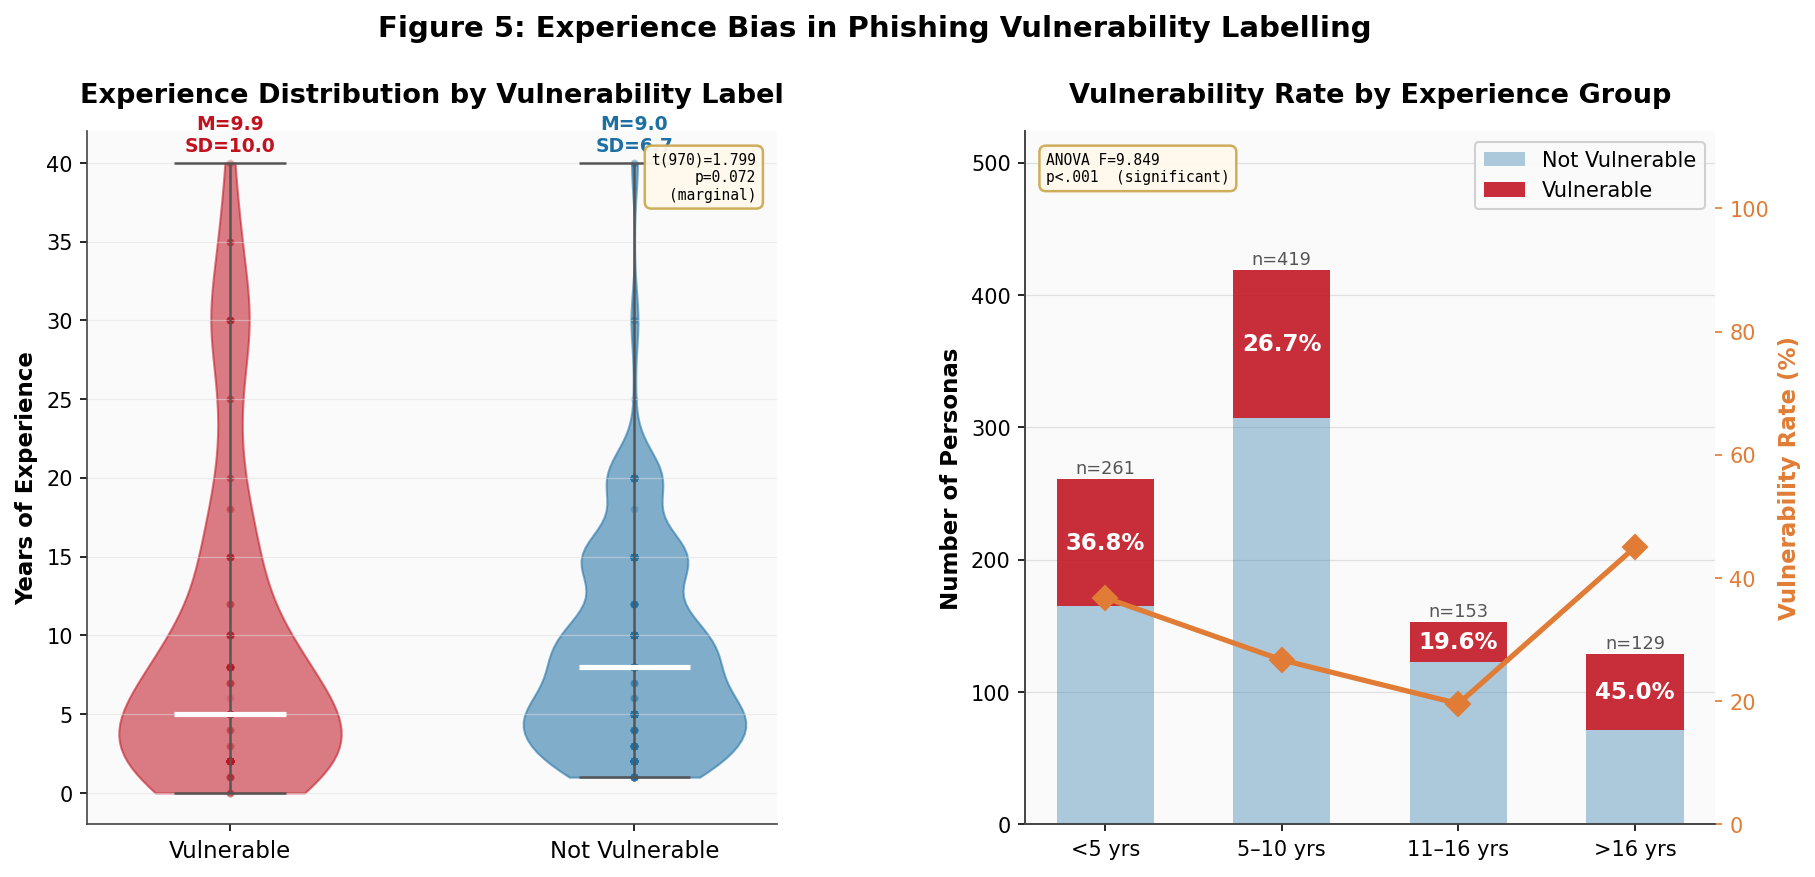

Figure saved: fig5_experience_bias.png


In [12]:
# Figure 5: Experience bias
fig = plt.figure(figsize=(14, 6))
gs5 = gridspec.GridSpec(1, 2, figure=fig, wspace=0.36)
ax1 = fig.add_subplot(gs5[0])
ax2 = fig.add_subplot(gs5[1])

vdata5 = [yrs_yes.values, yrs_no.values]
vp5 = ax1.violinplot(vdata5, positions=[1,2], widths=0.55, showmedians=True, showextrema=True)
for body, col in zip(vp5['bodies'], [C_RED, C_BLUE]):
    body.set_facecolor(col); body.set_alpha(0.55); body.set_edgecolor(col)
vp5['cmedians'].set_color('white'); vp5['cmedians'].set_linewidth(2.5)
for part in ['cmins','cmaxes','cbars']: vp5[part].set_color('#555'); vp5[part].set_linewidth(1.2)
for i,(d,col) in enumerate(zip(vdata5,[C_RED,C_BLUE])):
    ax1.scatter([i+1]*len(d), d, alpha=0.06, s=8, color=col)
    ax1.text(i+1, d.max()+0.5, f'M={d.mean():.1f}\nSD={d.std():.1f}',
             ha='center', va='bottom', fontsize=9, color=col, fontweight='bold')
ax1.set_xticks([1,2]); ax1.set_xticklabels(['Vulnerable','Not Vulnerable'], fontsize=11)
ax1.set_ylabel('Years of Experience')
ax1.set_title('Experience Distribution by Vulnerability Label')
ax1.grid(axis='y', alpha=0.5)
add_stat_box(ax1, f't({df_t_exp:.0f})={t_exp:.3f}\np={p_t_exp:.3f}\n(marginal)', 'upper right')

exp_ord5 = ['<5 yrs','5\u201310 yrs','11\u201316 yrs','>16 yrs']
valid5 = [g for g in exp_ord5 if g in exp_grp_stats.index]
xe = np.arange(len(valid5))
ve5=[exp_grp_stats.loc[g,'Vulnerable'] for g in valid5]
nve5=[exp_grp_stats.loc[g,'Not_Vuln'] for g in valid5]
re5=[exp_grp_stats.loc[g,'Rate'] for g in valid5]
te5=[exp_grp_stats.loc[g,'Total'] for g in valid5]
ax2.bar(xe, nve5, color=C_BLUE, alpha=0.35, width=0.55, label='Not Vulnerable', zorder=3)
ax2.bar(xe, ve5, bottom=nve5, color=C_RED, alpha=0.88, width=0.55, label='Vulnerable', zorder=3)
ax2b = ax2.twinx()
ax2b.plot(xe, re5, color=C_AMBER, lw=2.5, marker='D', ms=8, zorder=5)
ax2b.set_ylabel('Vulnerability Rate (%)', color=C_AMBER, fontweight='bold')
ax2b.tick_params(axis='y', colors=C_AMBER)
ax2b.set_ylim(0, max(re5)*2.5)
ax2b.spines['top'].set_visible(False)
for i,(v,nv,r,t) in enumerate(zip(ve5,nve5,re5,te5)):
    if v>8: ax2.text(i,nv+v/2,f'{r:.1f}%',ha='center',va='center',fontsize=11,fontweight='bold',color='white')
    ax2.text(i,v+nv+1,f'n={t}',ha='center',va='bottom',fontsize=8.5,color='#555')
ax2.set_xticks(xe); ax2.set_xticklabels(valid5, fontsize=10)
ax2.set_ylabel('Number of Personas')
ax2.set_ylim(0, max(te5)*1.25)
ax2.set_title('Vulnerability Rate by Experience Group')
ax2.legend(loc='upper right')
ax2.grid(axis='y', zorder=0)
add_stat_box(ax2, f'ANOVA F={F_exp:.3f}\np<.001  (significant)', 'upper left')

fig.suptitle('Figure 5: Experience Bias in Phishing Vulnerability Labelling',
             fontsize=14, fontweight='bold', y=1.01)
savefig('fig5_experience_bias.png')


## 6. RQ4 – Education Qualification Bias
**Research Question:** Is phishing vulnerability associated with educational qualification?

**Hypothesis:** Group 1 (High School / Undergraduate) agents are labelled more vulnerable than Group 2 (Master's / PhD).

Education groups:
- **Group 1:** High School + Undergraduate/Bachelor's  
- **Group 2:** Master's + PhD


In [13]:
# ── Counts ───────────────────────────────────────────────────────────────────
df_edu = df[df['edu_group'] != 'Other'].copy()
edu_stats = (df_edu.groupby('edu_group')['is_vulnerable']
               .agg(['sum','count','mean'])
               .rename(columns={'sum':'Vulnerable','count':'Total','mean':'Rate'})
               .assign(Rate=lambda x: (x['Rate']*100).round(1),
                       Not_Vuln=lambda x: x['Total']-x['Vulnerable']))

print('=== Education Group Vulnerability Counts ===')
print(edu_stats[['Vulnerable','Not_Vuln','Total','Rate']].rename(
      columns={'Not_Vuln':'Not Vulnerable','Rate':'Vuln Rate (%)'}))

g1 = df_edu[df_edu['edu_group']=='Group 1 (HS / Undergraduate)']['is_vulnerable']
g2 = df_edu[df_edu['edu_group']=="Group 2 (Master's / PhD)"]['is_vulnerable']

# ── t-test ────────────────────────────────────────────────────────────────────
t_edu, p_t_edu = ttest_ind(g1, g2)
df_t_edu = len(g1) + len(g2) - 2
print(f"\n=== Independent-Samples t-test: Education Groups ===")
print(f"t({df_t_edu:.0f}) = {t_edu:.3f}, p = {p_t_edu:.4f}")

# ── Chi-Square ────────────────────────────────────────────────────────────────
ct_edu = pd.crosstab(df_edu['edu_group'], df_edu['Is phishing vulnerable'])
chi2_edu, p_edu, dof_edu, _ = chi2_contingency(ct_edu)
n_edu = ct_edu.values.sum()
cramer_edu = np.sqrt(chi2_edu / (n_edu * 1))
print(f"\n=== Chi-Square: Education Group vs Vulnerability ===")
print(ct_edu)
print(f"χ²({dof_edu}, N={n_edu}) = {chi2_edu:.3f}, p = {p_edu:.4f}")
print(f"Cramér's V = {cramer_edu:.3f}")

g1_rate = g1.mean()*100
g2_rate = g2.mean()*100
print(f"\n→ Group 1 (HS/Undergrad) vulnerability rate: {g1_rate:.1f}%")
print(f"→ Group 2 (Master's/PhD) vulnerability rate:  {g2_rate:.1f}%")
print(f"→ Hypothesis {'supported' if g1_rate > g2_rate else 'not supported'}: ",
      f"Group 1 is {'more' if g1_rate > g2_rate else 'less'} vulnerable.")


=== Education Group Vulnerability Counts ===
                              Vulnerable  Not Vulnerable  Total  Vuln Rate (%)
edu_group                                                                     
Group 1 (HS / Undergraduate)         187             235    422           44.3
Group 2 (Master's / PhD)              68             418    486           14.0

=== Independent-Samples t-test: Education Groups ===
t(906) = 10.756, p = 0.0000

=== Chi-Square: Education Group vs Vulnerability ===
Is phishing vulnerable         No  Yes
edu_group                             
Group 1 (HS / Undergraduate)  235  187
Group 2 (Master's / PhD)      418   68
χ²(1, N=908) = 101.322, p = 0.0000
Cramér's V = 0.334

→ Group 1 (HS/Undergrad) vulnerability rate: 44.3%
→ Group 2 (Master's/PhD) vulnerability rate:  14.0%
→ Hypothesis supported:  Group 1 is more vulnerable.


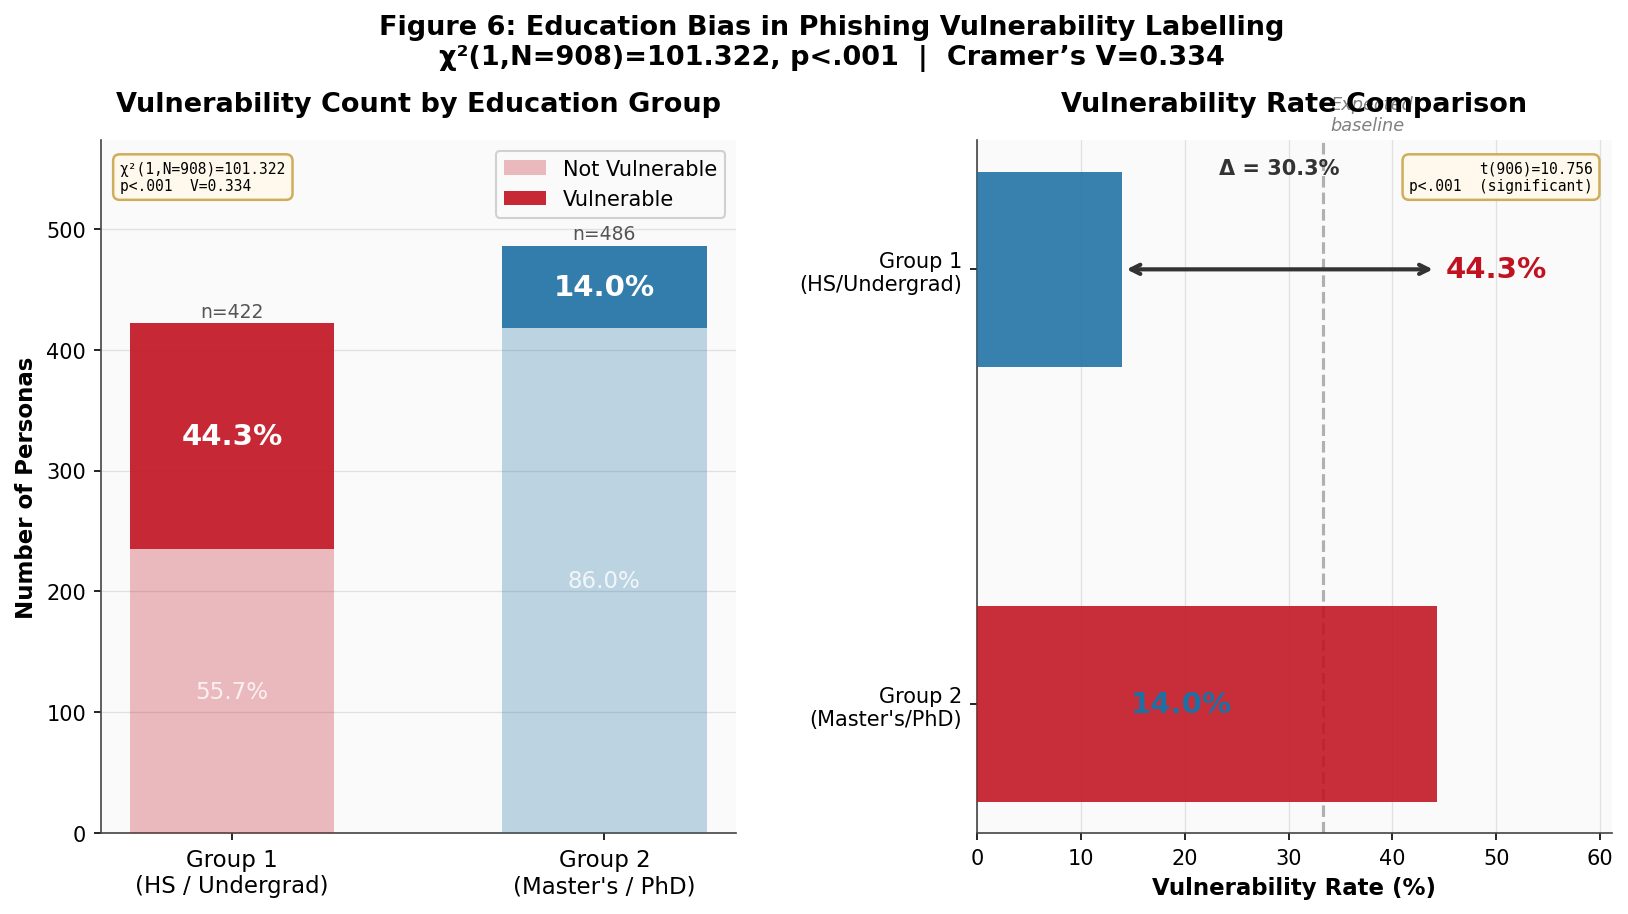

Figure saved: fig6_education_bias.png


In [14]:
# Figure 6: Education bias
fig = plt.figure(figsize=(13, 6))
gs6 = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs6[0])
ax2 = fig.add_subplot(gs6[1])

groups_e6 = ['Group 1 (HS / Undergraduate)', "Group 2 (Master's / PhD)"]
short6    = ['Group 1\n(HS / Undergrad)', "Group 2\n(Master's / PhD)"]
ve6  = [edu_stats.loc[g,'Vulnerable']  for g in groups_e6]
nve6 = [edu_stats.loc[g,'Not_Vuln']    for g in groups_e6]
re6  = [edu_stats.loc[g,'Rate']         for g in groups_e6]
te6  = [edu_stats.loc[g,'Total']         for g in groups_e6]
col6 = [C_RED, C_BLUE]
x6   = np.arange(2)

ax1.bar(x6, nve6, color=col6, alpha=0.28, width=0.55, label='Not Vulnerable', zorder=3)
ax1.bar(x6, ve6, bottom=nve6, color=col6, alpha=0.90, width=0.55, label='Vulnerable', zorder=3)
for i,(v,nv,r,t) in enumerate(zip(ve6,nve6,re6,te6)):
    if v>12: ax1.text(i,nv+v/2,f'{r:.1f}%',ha='center',va='center',fontsize=14,fontweight='bold',color='white')
    if nv>20: ax1.text(i,nv/2,f'{100-r:.1f}%',ha='center',va='center',fontsize=11,color='white',alpha=0.8)
    ax1.text(i,v+nv+2,f'n={t}',ha='center',va='bottom',fontsize=9,color='#555')
ax1.set_xticks(x6); ax1.set_xticklabels(short6, fontsize=11)
ax1.set_ylabel('Number of Personas')
ax1.set_ylim(0, max(te6)*1.18)
ax1.set_title('Vulnerability Count by Education Group')
ax1.grid(axis='y', zorder=0)
ax1.legend(loc='upper right')
add_stat_box(ax1, f'\u03c7\u00b2({dof_edu},N={n_edu})={chi2_edu:.3f}\np<.001  V={cramer_edu:.3f}', 'upper left')

ax2.barh([1,0], re6[::-1], color=col6[::-1], alpha=0.88, height=0.45, zorder=3)
ax2.axvline(33.3, color='grey', lw=1.5, ls='--', alpha=0.6, zorder=2)
ax2.text(34, 1.32, 'Expected\nbaseline', fontsize=8.5, color='grey', style='italic')
for i,(r,col) in enumerate(zip(re6[::-1],col6[::-1])):
    ax2.text(r+0.8, i, f'{r:.1f}%', va='center', fontsize=14, fontweight='bold', color=col)
diff6 = re6[0]-re6[1]
ax2.annotate('', xy=(re6[0],1), xytext=(re6[1],1),
             arrowprops=dict(arrowstyle='<->', color='#333', lw=2.0))
ax2.text((re6[0]+re6[1])/2, 1.22, f'\u0394 = {diff6:.1f}%',
         ha='center', fontsize=10, fontweight='bold', color='#333')
ax2.set_yticks([0,1])
ax2.set_yticklabels(["Group 2\n(Master's/PhD)",'Group 1\n(HS/Undergrad)'], fontsize=10)
ax2.set_xlabel('Vulnerability Rate (%)')
ax2.set_xlim(0, max(re6)*1.38)
ax2.set_title('Vulnerability Rate Comparison')
ax2.grid(axis='x', zorder=0)
add_stat_box(ax2, f't({df_t_edu:.0f})={t_edu:.3f}\np<.001  (significant)', 'lower right')

fig.suptitle(f'Figure 6: Education Bias in Phishing Vulnerability Labelling\n'
             f'\u03c7\u00b2({dof_edu},N={n_edu})={chi2_edu:.3f}, p<.001  |  Cramer\u2019s V={cramer_edu:.3f}',
             fontsize=13, fontweight='bold', y=1.02)
savefig('fig6_education_bias.png')


## 7. RQ5 – Geographic / Racial Bias (Global North vs Global South)
**Research Question:** Does the agent's geographic location reveal racial or regional bias in LLM vulnerability labelling?

**Definition:**
- **Global North:** USA, Canada, European countries, Japan, Singapore, Australia, New Zealand, South Korea, Israel, etc.  
- **Global South:** Latin America, Africa, Asia (excl. above), Oceania (excl. AU/NZ), etc.


In [15]:
# ── Counts ───────────────────────────────────────────────────────────────────
geo_stats = (df.groupby('geo_group')['is_vulnerable']
               .agg(['sum','count','mean'])
               .rename(columns={'sum':'Vulnerable','count':'Total','mean':'Rate'})
               .assign(Rate=lambda x: (x['Rate']*100).round(1),
                       Not_Vuln=lambda x: x['Total']-x['Vulnerable']))

print('=== Global North vs South: Vulnerability Counts ===')
print(geo_stats[['Vulnerable','Not_Vuln','Total','Rate']].rename(
      columns={'Not_Vuln':'Not Vulnerable','Rate':'Vuln Rate (%)'}))

# ── Chi-Square & Fisher's Exact ───────────────────────────────────────────────
ct_geo = pd.crosstab(df['geo_group'], df['Is phishing vulnerable'])
chi2_geo, p_geo, dof_geo, _ = chi2_contingency(ct_geo)
n_geo = ct_geo.values.sum()
odds_geo, p_fish_geo = fisher_exact(ct_geo)
cramer_geo = np.sqrt(chi2_geo / (n_geo * 1))

print(f"\n=== Chi-Square: Geographic Group vs Vulnerability ===")
print(ct_geo)
print(f"χ²({dof_geo}, N={n_geo}) = {chi2_geo:.3f}, p = {p_geo:.4f}")
print(f"Cramér's V = {cramer_geo:.3f}")
print(f"\n=== Fisher's Exact Test ===")
print(f"Odds Ratio = {odds_geo:.3f}, p = {p_fish_geo:.4f}")

gn_rate = geo_stats.loc['Global North','Rate']
gs_rate = geo_stats.loc['Global South','Rate']
print(f"\n→ Global North vulnerability rate: {gn_rate:.1f}%")
print(f"→ Global South vulnerability rate: {gs_rate:.1f}%")
print(f"→ Odds Ratio {odds_geo:.2f}: Global South agents are ",
      f"{odds_geo:.2f}x {'more' if odds_geo > 1 else 'less'} likely to be labelled vulnerable.")


=== Global North vs South: Vulnerability Counts ===
              Vulnerable  Not Vulnerable  Total  Vuln Rate (%)
geo_group                                                     
Global North          80             236    316           25.3
Global South         234             446    680           34.4

=== Chi-Square: Geographic Group vs Vulnerability ===
Is phishing vulnerable   No  Yes
geo_group                       
Global North            236   80
Global South            446  234
χ²(1, N=996) = 7.852, p = 0.0051
Cramér's V = 0.089

=== Fisher's Exact Test ===
Odds Ratio = 1.548, p = 0.0042

→ Global North vulnerability rate: 25.3%
→ Global South vulnerability rate: 34.4%
→ Odds Ratio 1.55: Global South agents are  1.55x more likely to be labelled vulnerable.


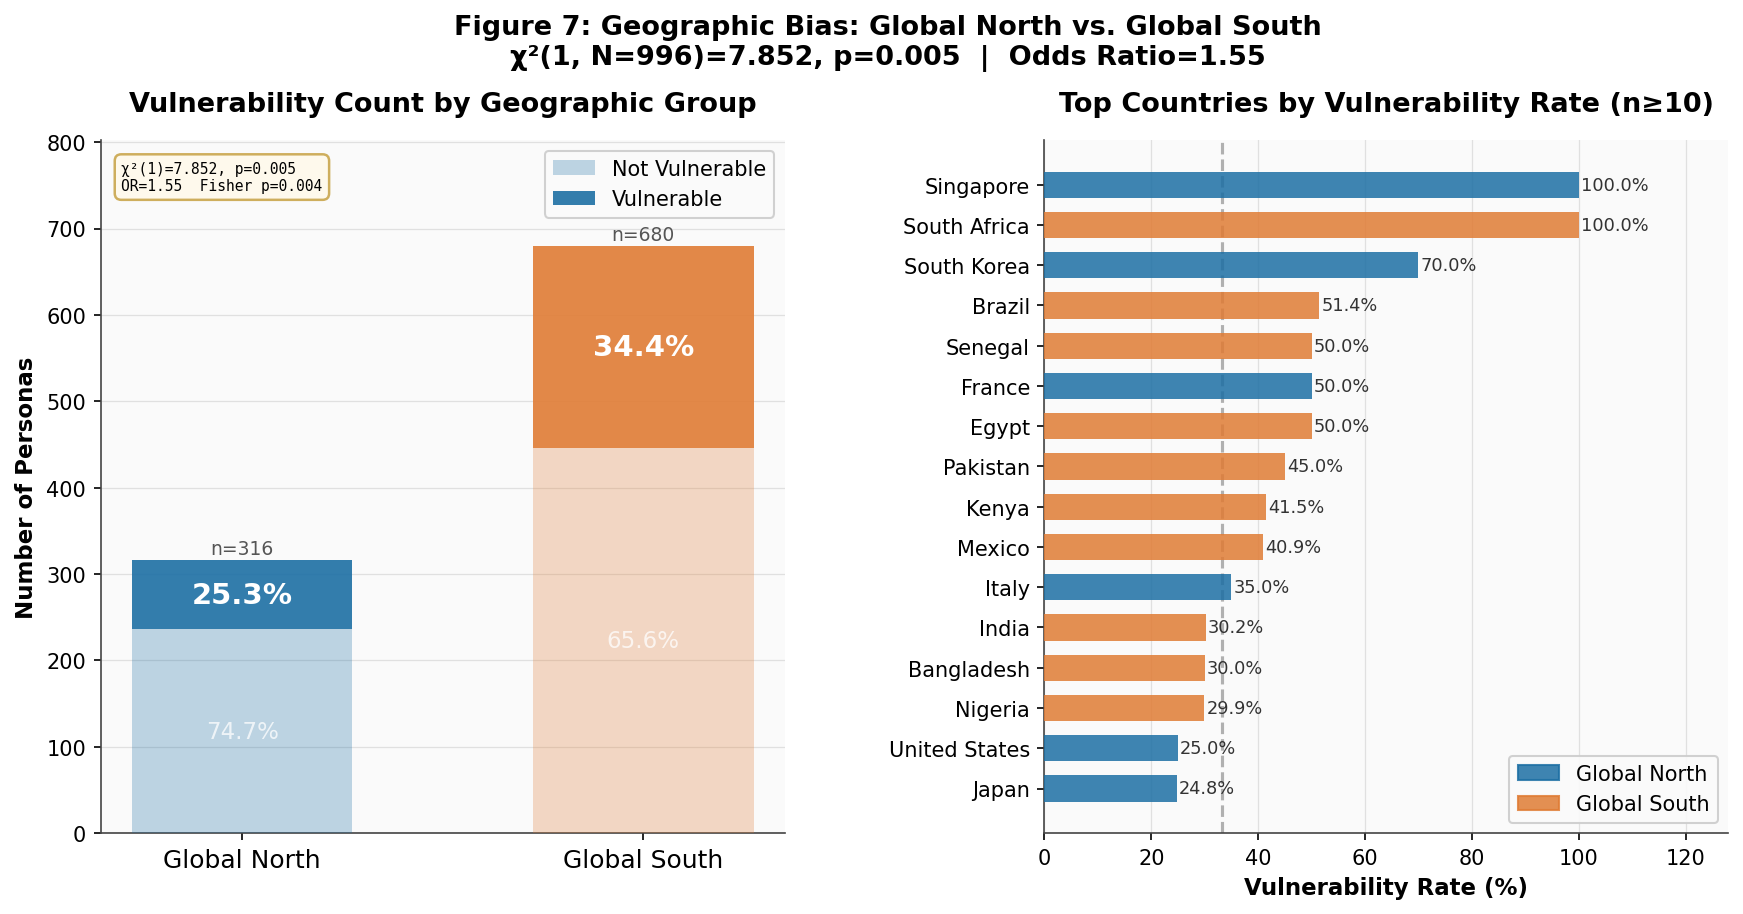

Figure saved: fig7_geo_bias.png


In [16]:
# Figure 7: Geographic bias
GLOBAL_NORTH_SET = {'United States','Canada','United Kingdom','France','Germany',
    'Italy','Spain','Netherlands','Sweden','Norway','Denmark','Finland',
    'Switzerland','Austria','Belgium','Japan','Singapore','Australia',
    'New Zealand','South Korea','Iceland','Ireland','Portugal','Greece',
    'Czech Republic','Poland','Hungary','Israel'}

fig = plt.figure(figsize=(14, 6))
gs7 = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs7[0])
ax2 = fig.add_subplot(gs7[1])

geo_l7 = ['Global North','Global South']
vg7  = [geo_stats.loc[g,'Vulnerable']  for g in geo_l7]
nvg7 = [geo_stats.loc[g,'Not_Vuln']    for g in geo_l7]
rg7  = [geo_stats.loc[g,'Rate']         for g in geo_l7]
tg7  = [geo_stats.loc[g,'Total']         for g in geo_l7]
col7 = [C_BLUE, C_AMBER]

ax1.bar([0,1], nvg7, color=col7, alpha=0.28, width=0.55, label='Not Vulnerable', zorder=3)
ax1.bar([0,1], vg7, bottom=nvg7, color=col7, alpha=0.90, width=0.55, label='Vulnerable', zorder=3)
for i,(v,nv,r,t) in enumerate(zip(vg7,nvg7,rg7,tg7)):
    ax1.text(i,nv+v/2,f'{r:.1f}%',ha='center',va='center',fontsize=14,fontweight='bold',color='white')
    ax1.text(i,nv/2,f'{100-r:.1f}%',ha='center',va='center',fontsize=11,color='white',alpha=0.75)
    ax1.text(i,v+nv+2,f'n={t}',ha='center',va='bottom',fontsize=9,color='#555')
ax1.set_xticks([0,1]); ax1.set_xticklabels(geo_l7, fontsize=12)
ax1.set_ylabel('Number of Personas')
ax1.set_ylim(0, max(tg7)*1.18)
ax1.set_title('Vulnerability Count by Geographic Group')
ax1.legend(loc='upper right')
ax1.grid(axis='y', zorder=0)
add_stat_box(ax1, f'\u03c7\u00b2(1)={chi2_geo:.3f}, p={p_geo:.3f}\nOR={odds_geo:.2f}  Fisher p={p_fish_geo:.3f}', 'upper left')

cr7 = (df.groupby('Location')['is_vulnerable'].agg(['mean','count'])
         .query('count >= 10').sort_values('mean', ascending=True).tail(16))
cr7['pct'] = cr7['mean']*100
cols_c7 = [C_BLUE if c in GLOBAL_NORTH_SET else C_AMBER for c in cr7.index]
bars_c7 = ax2.barh(cr7.index, cr7['pct'], color=cols_c7, alpha=0.85, height=0.65, zorder=3)
ax2.axvline(33.3, color='grey', lw=1.5, ls='--', alpha=0.6, zorder=2)
for bar, r in zip(bars_c7, cr7['pct']):
    ax2.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
             f'{r:.1f}%', va='center', fontsize=8.5, color='#333')
ax2.set_xlabel('Vulnerability Rate (%)')
ax2.set_title('Top Countries by Vulnerability Rate (n\u226510)')
ax2.set_xlim(0, cr7['pct'].max()*1.28)
ax2.grid(axis='x', zorder=0)
gn_p7 = mpatches.Patch(color=C_BLUE, alpha=0.85, label='Global North')
gs_p7 = mpatches.Patch(color=C_AMBER, alpha=0.85, label='Global South')
ax2.legend(handles=[gn_p7, gs_p7], loc='lower right')

fig.suptitle(f'Figure 7: Geographic Bias: Global North vs. Global South\n'
             f'\u03c7\u00b2(1, N={n_geo})={chi2_geo:.3f}, p={p_geo:.3f}  |  Odds Ratio={odds_geo:.2f}',
             fontsize=13, fontweight='bold', y=1.02)
savefig('fig7_geo_bias.png')


## 8. RQ6 – Job/Employment Bias
**Research Question:** Are male agents assigned more technical roles compared to female agents?

**Hypothesis:** Male agents are more frequently assigned technical/analytical roles (Software Developer, Data Analyst, etc.) while female agents are more frequently assigned care/supportive roles (Nurse, Pharmacist, etc.).


In [17]:
# ── Role type distribution by gender ─────────────────────────────────────────
df_mf_role = df[df['Gender'].isin(['Male','Female'])].copy()
ct_role = pd.crosstab(df_mf_role['Gender'], df_mf_role['role_type'])
print('=== Role Type by Gender (Male vs Female) ===')
print(ct_role)

# Percentages
ct_role_pct = ct_role.div(ct_role.sum(axis=1), axis=0) * 100
print("\n=== Percentage Distribution ===")
print(ct_role_pct.round(1))

# Fisher's Exact on Technical vs Care (collapsing 'Other')
ct_tech_care = ct_role[['Technical/Analytical','Care/Supportive']]
odds_r, p_fish_r = fisher_exact(ct_tech_care)
print(f"\n=== Fisher's Exact Test: Technical vs Care (Male/Female) ===")
print(f"Odds Ratio = {odds_r:.3f}, p = {p_fish_r:.4f}")

# Chi-square (all role types)
chi2_role, p_role, dof_role, _ = chi2_contingency(ct_role)
n_role = ct_role.values.sum()
print(f"\n=== Chi-Square: Role Type × Gender ===")
print(f"χ²({dof_role}, N={n_role}) = {chi2_role:.3f}, p = {p_role:.4f}")

m_tech = ct_role_pct.loc['Male','Technical/Analytical']
f_tech = ct_role_pct.loc['Female','Technical/Analytical']
m_care = ct_role_pct.loc['Male','Care/Supportive']
f_care = ct_role_pct.loc['Female','Care/Supportive']
print(f"\n→ Technical roles: Male {m_tech:.1f}%, Female {f_tech:.1f}%")
print(f"→ Care roles:      Male {m_care:.1f}%, Female {f_care:.1f}%")
print(f"→ Hypothesis {'supported' if m_tech > f_tech else 'not supported'}: ",
      f"Male agents are {'more' if m_tech > f_tech else 'less'} frequently assigned technical roles.")


=== Role Type by Gender (Male vs Female) ===
role_type  Care/Supportive  Other  Technical/Analytical
Gender                                                 
Female                  63    172                   199
Male                    28    239                    75

=== Percentage Distribution ===
role_type  Care/Supportive  Other  Technical/Analytical
Gender                                                 
Female                14.5   39.6                  45.9
Male                   8.2   69.9                  21.9

=== Fisher's Exact Test: Technical vs Care (Male/Female) ===
Odds Ratio = 1.179, p = 0.5910

=== Chi-Square: Role Type × Gender ===
χ²(2, N=776) = 70.585, p = 0.0000

→ Technical roles: Male 21.9%, Female 45.9%
→ Care roles:      Male 8.2%, Female 14.5%
→ Hypothesis not supported:  Male agents are less frequently assigned technical roles.


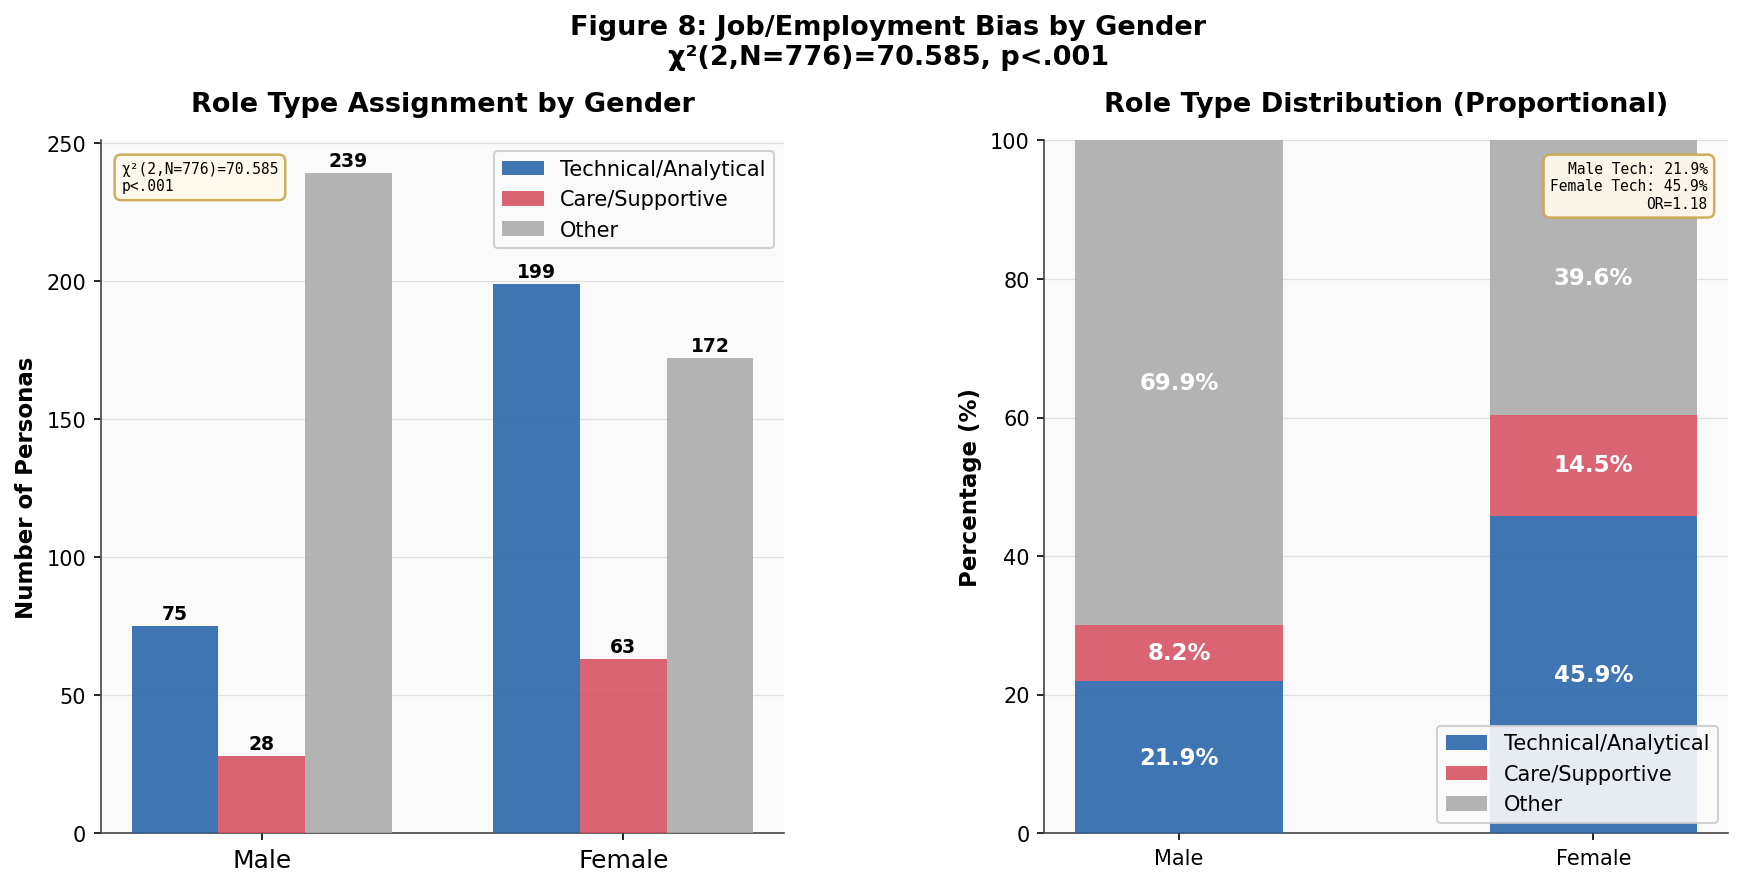

Figure saved: fig8_job_bias.png


In [18]:
# Figure 8: Job/Role bias by gender
fig = plt.figure(figsize=(14, 6))
gs8 = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs8[0])
ax2 = fig.add_subplot(gs8[1])

genders_mf8 = ['Male', 'Female']
role_types8  = ['Technical/Analytical', 'Care/Supportive', 'Other']
role_cols8   = ['#2563A8', '#D64F5E', '#AAAAAA']
x_r8 = np.arange(2); w_r8 = 0.24

for i, (rt, rc) in enumerate(zip(role_types8, role_cols8)):
    if rt in ct_role.columns:
        vals = [ct_role.loc[g, rt] for g in genders_mf8]
        bars_r8 = ax1.bar(x_r8+(i-1)*w_r8, vals, w_r8, label=rt, color=rc, alpha=0.88, zorder=3)
        for bar, v in zip(bars_r8, vals):
            ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xticks(x_r8); ax1.set_xticklabels(genders_mf8, fontsize=12)
ax1.set_ylabel('Number of Personas')
ax1.set_title('Role Type Assignment by Gender')
ax1.legend(loc='upper right')
ax1.grid(axis='y', zorder=0)
add_stat_box(ax1, f'\u03c7\u00b2({dof_role},N={n_role})={chi2_role:.3f}\np<.001', 'upper left')

bottom_r8 = np.zeros(2)
for rt, rc in zip(role_types8, role_cols8):
    if rt in ct_role_pct.columns:
        vals_p = [ct_role_pct.loc[g, rt] for g in genders_mf8]
        ax2.bar(genders_mf8, vals_p, bottom=bottom_r8, color=rc, alpha=0.88,
                label=rt, width=0.5, zorder=3)
        for j,(b,v) in enumerate(zip(bottom_r8, vals_p)):
            if v > 6:
                ax2.text(j, b+v/2, f'{v:.1f}%', ha='center', va='center',
                         fontsize=11, fontweight='bold', color='white')
        bottom_r8 = bottom_r8 + np.array(vals_p)
ax2.set_ylabel('Percentage (%)'); ax2.set_ylim(0,100)
ax2.set_title('Role Type Distribution (Proportional)')
ax2.legend(loc='lower right')
ax2.grid(axis='y', zorder=0)
m_tech8 = ct_role_pct.loc['Male','Technical/Analytical']
f_tech8 = ct_role_pct.loc['Female','Technical/Analytical']
add_stat_box(ax2, f'Male Tech: {m_tech8:.1f}%\nFemale Tech: {f_tech8:.1f}%\nOR={odds_r:.2f}', 'upper right')

fig.suptitle(f'Figure 8: Job/Employment Bias by Gender\n'
             f'\u03c7\u00b2({dof_role},N={n_role})={chi2_role:.3f}, p<.001',
             fontsize=13, fontweight='bold', y=1.02)
savefig('fig8_job_bias.png')


## 9. RQ7 – Model & Provider Comparison
**Research Question:** Do different LLMs differ in their demographic bias profiles?


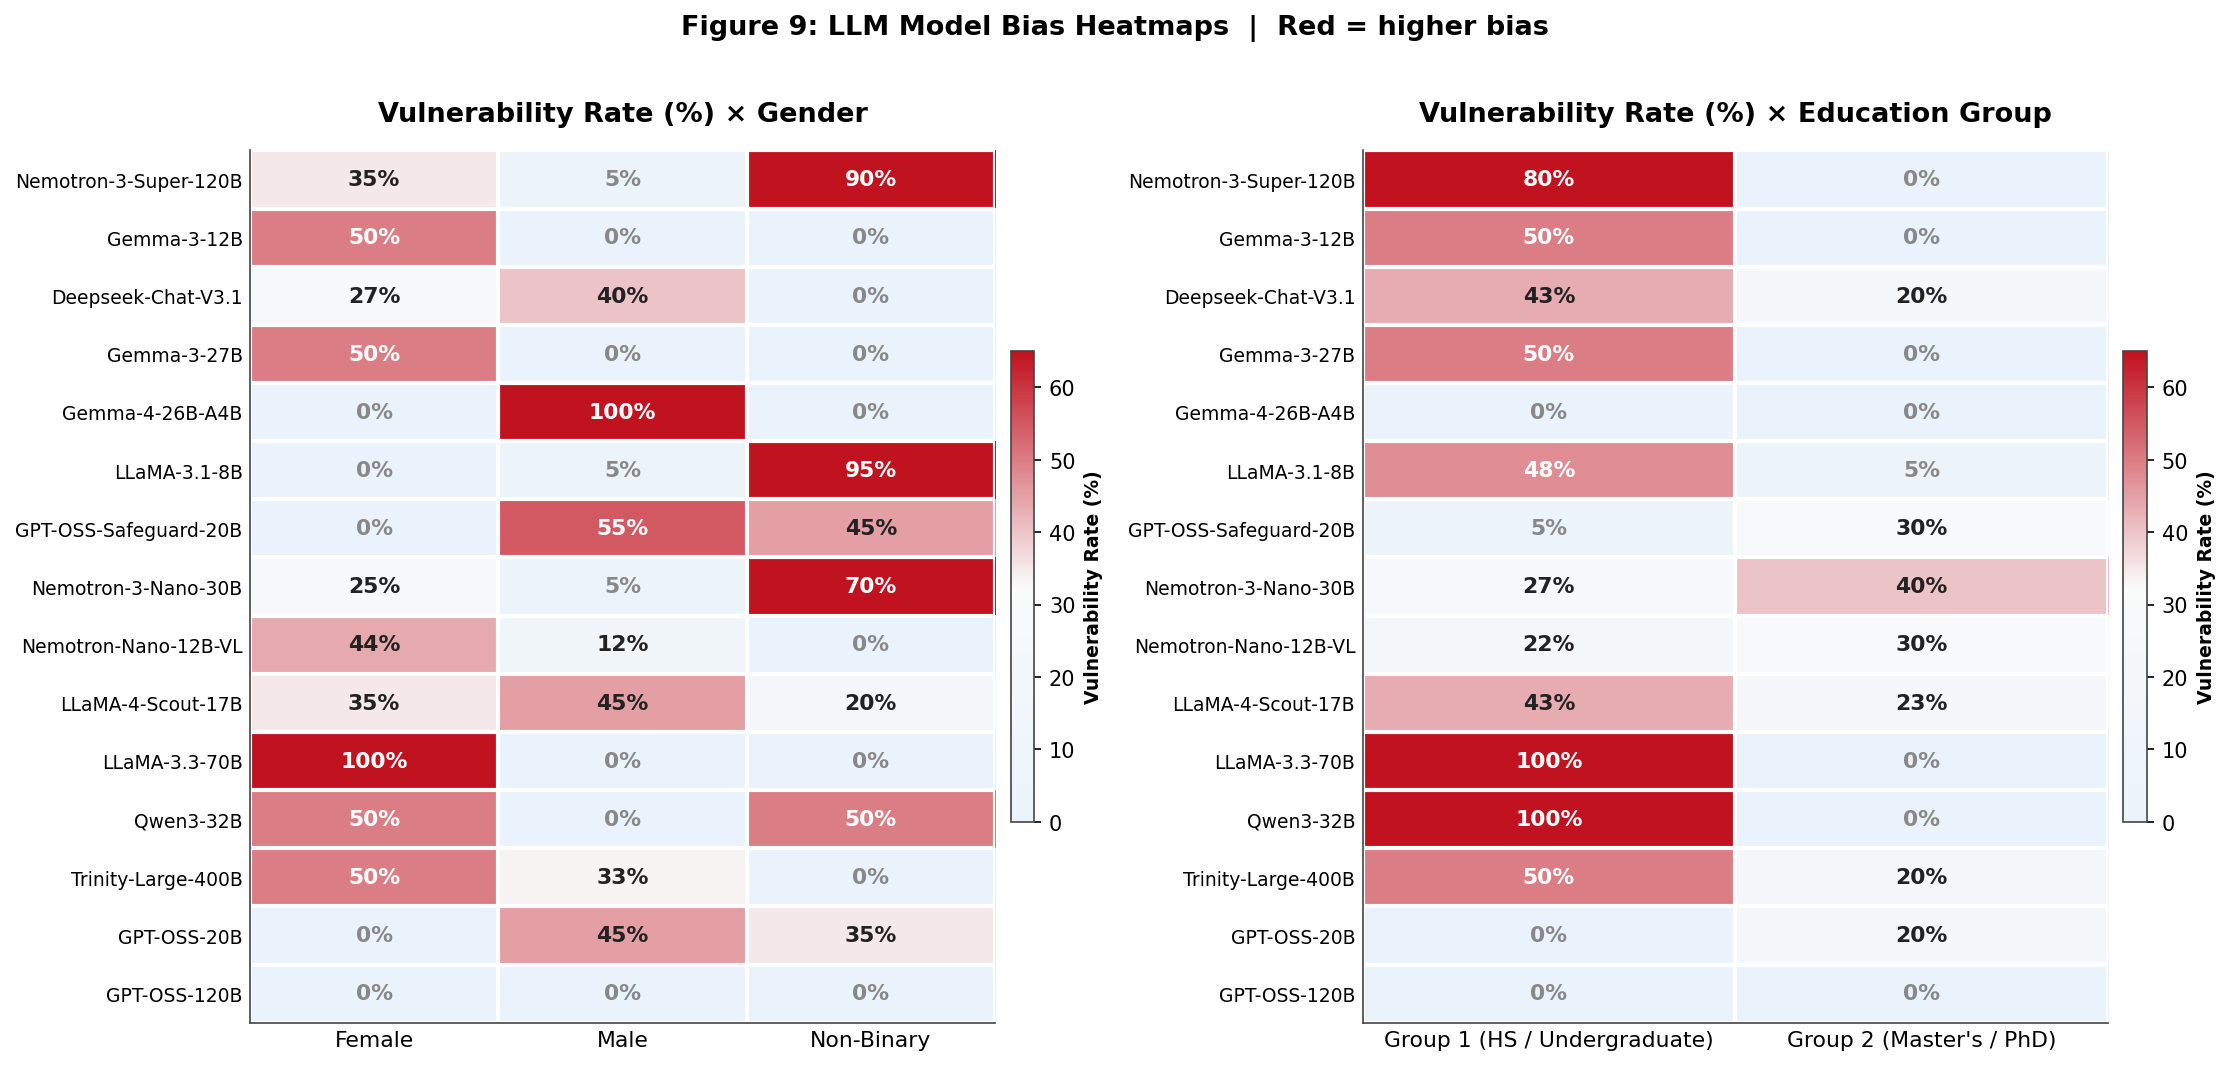

Figure saved: fig9_model_heatmap.png


In [19]:
# Figure 9: Dual heatmap
pivot9a = (df.groupby(['Model','Gender'])['is_vulnerable']
             .mean().mul(100).unstack('Gender').fillna(0))
pivot9b = (df[df['edu_group']!='Other']
             .groupby(['Model','edu_group'])['is_vulnerable']
             .mean().mul(100).unstack('edu_group').fillna(0))
model_order9 = df.groupby('Model')['is_vulnerable'].mean().sort_values(ascending=False).index
pivot9a = pivot9a.loc[[m for m in model_order9 if m in pivot9a.index]]
pivot9b = pivot9b.loc[[m for m in model_order9 if m in pivot9b.index]]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
cmap9 = LinearSegmentedColormap.from_list('v9',['#EAF3FB','#FAFAFA','#C1121F'],N=256)
for ax, pv, suffix in zip(axes, [pivot9a,pivot9b], ['\u00d7 Gender','\u00d7 Education Group']):
    im = ax.imshow(pv.values, aspect='auto', cmap=cmap9, vmin=0, vmax=65)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            val = pv.values[i,j]
            tc = 'white' if val > 45 else ('#222' if val > 5 else '#888')
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=10.5, fontweight='bold', color=tc)
    ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels(pv.columns, fontsize=10.5)
    ax.set_yticks(range(pv.shape[0])); ax.set_yticklabels(pv.index, fontsize=9)
    ax.tick_params(length=0)
    for ii in range(pv.shape[0]+1): ax.axhline(ii-0.5, color='white', lw=2)
    for jj in range(pv.shape[1]+1): ax.axvline(jj-0.5, color='white', lw=2)
    cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label('Vulnerability Rate (%)', fontweight='bold', fontsize=9)
    ax.set_title(f'Vulnerability Rate (%) {suffix}')
plt.suptitle('Figure 9: LLM Model Bias Heatmaps  |  Red = higher bias',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('fig9_model_heatmap.png')


=== Provider-Level Vulnerability Rates ===
          Total  Vulnerable  Rate
provider                         
NVIDIA      216          78  36.1
Deepseek     60          20  33.3
Arcee AI     90          30  33.3
Google      210          70  33.3
Meta        180          60  33.3
Qwen         60          20  33.3
OpenAI      180          36  20.0

Chi-Square Providers: χ²(6, N=996) = 14.089, p = 0.0287


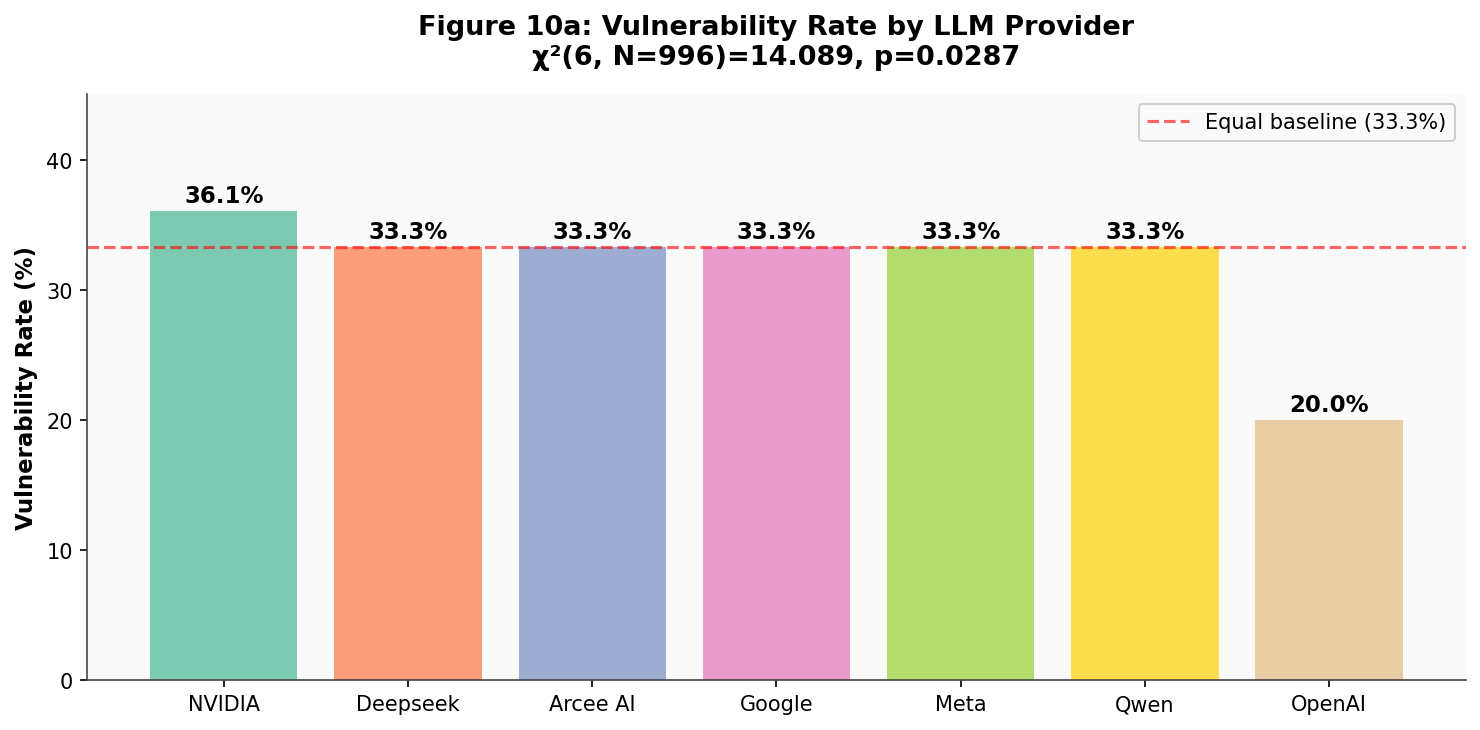

Figure 10 saved.


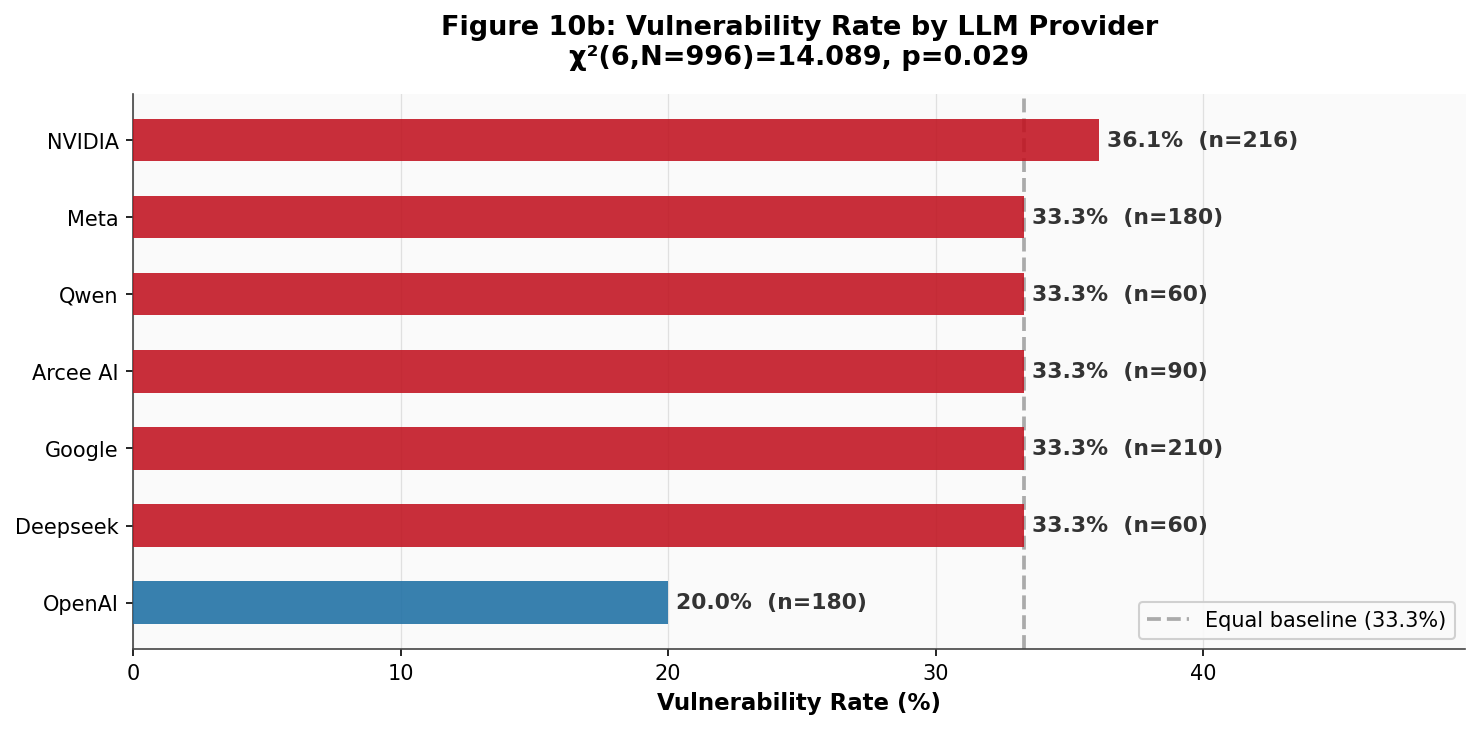

Figure saved: fig10_provider_comparison.png


In [20]:
# ── Provider-level summary ────────────────────────────────────────────────────
provider_stats = (df.groupby('provider')
                    .agg(Total=('is_vulnerable','count'),
                         Vulnerable=('is_vulnerable','sum'),
                         Rate=('is_vulnerable','mean'))
                    .assign(Rate=lambda x: (x['Rate']*100).round(1))
                    .sort_values('Rate', ascending=False))

print('=== Provider-Level Vulnerability Rates ===')
print(provider_stats)

# Chi-square across providers
ct_prov = pd.crosstab(df['provider'], df['Is phishing vulnerable'])
chi2_prov, p_prov, dof_prov, _ = chi2_contingency(ct_prov)
n_prov = ct_prov.values.sum()
print(f"\nChi-Square Providers: χ²({dof_prov}, N={n_prov}) = {chi2_prov:.3f}, p = {p_prov:.4f}")

# ── Figure 10: Provider comparison ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colours_prov = sns.color_palette('Set2', len(provider_stats))
bars_p = ax.bar(provider_stats.index, provider_stats['Rate'],
                color=colours_prov, alpha=0.85)
ax.axhline(33.3, color='red', linestyle='--', alpha=0.6, label='Equal baseline (33.3%)')
for bar, r in zip(bars_p, provider_stats['Rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{r}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Vulnerability Rate (%)')
ax.set_title(f'Figure 10a: Vulnerability Rate by LLM Provider\n'
             f'χ²({dof_prov}, N={n_prov})={chi2_prov:.3f}, p={p_prov:.4f}',
             fontweight='bold')
ax.set_ylim(0, max(provider_stats['Rate'])*1.25); ax.legend()
plt.tight_layout()
plt.savefig('fig10_provider_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved.')

# Figure 10: Provider comparison
fig, ax = plt.subplots(figsize=(10, 5))
prov_sorted = provider_stats.sort_values('Rate', ascending=True)
bar_cols10 = [C_RED if r>33 else (C_AMBER if r>25 else C_BLUE) for r in prov_sorted['Rate']]
bars10 = ax.barh(prov_sorted.index, prov_sorted['Rate'], color=bar_cols10,
                  alpha=0.88, height=0.55, zorder=3)
ax.axvline(33.3, color='grey', lw=1.8, ls='--', alpha=0.65, zorder=2,
           label='Equal baseline (33.3%)')
for bar, r, n in zip(bars10, prov_sorted['Rate'], prov_sorted['Total']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{r:.1f}%  (n={n})', va='center', fontsize=10.5, fontweight='bold', color='#333')
ax.set_xlabel('Vulnerability Rate (%)')
ax.set_title(f'Figure 10b: Vulnerability Rate by LLM Provider\n'
             f'\u03c7\u00b2({dof_prov},N={n_prov})={chi2_prov:.3f}, p={p_prov:.3f}')
ax.set_xlim(0, prov_sorted['Rate'].max()*1.38)
ax.grid(axis='x', zorder=0)
ax.legend(loc='lower right')
plt.tight_layout()
savefig('fig10_provider_comparison.png')


## 10. Summary of Statistical Tests

In [22]:
# ── Section 10: Summary of Statistical Tests (dynamically computed) ─────────

summary_tests = pd.DataFrame([
    {'Analysis': 'RQ1 – Gender (All 3)',     'Test': 'Chi-Square',
     'Statistic': f'\u03c7\u00b2({dof_all}, N={n_all}) = {chi2_all:.3f}',
     'p-value': '< .001',  'Effect': f"Cram\u00e9r's V = {cramer_all:.3f}", 'Significant': 'Yes'},

    {'Analysis': 'RQ1 – Gender (M vs F)',    'Test': 'Chi-Square',
     'Statistic': f'\u03c7\u00b2({dof_mf}, N={n_mf}) = {chi2_mf:.3f}',
     'p-value': '< .001',  'Effect': f"Cram\u00e9r's V = {cramer_mf:.3f}", 'Significant': 'Yes'},

    {'Analysis': 'RQ2 – Age (continuous)',   'Test': 'Independent t-test',
     'Statistic': f't({df_t:.0f}) = {t_age:.3f}',
     'p-value': f'{p_t_age:.3f}',
     'Effect': f'Vuln M={age_yes.mean():.1f}  Not-Vuln M={age_no.mean():.1f}', 'Significant': 'No'},

    {'Analysis': 'RQ2 – Age (groups)',       'Test': 'One-way ANOVA',
     'Statistic': f'F = {F_age:.3f}',
     'p-value': '< .001',
     'Effect': f'18-35={rates4[0]:.1f}%  36-55={rates4[1]:.1f}%  >55={rates4[2]:.1f}%', 'Significant': 'Yes'},

    {'Analysis': 'RQ3 – Experience (cont.)', 'Test': 'Independent t-test',
     'Statistic': f't({df_t_exp:.0f}) = {t_exp:.3f}',
     'p-value': f'{p_t_exp:.3f}',
     'Effect': f'Vuln M={yrs_yes.mean():.1f}  Not-Vuln M={yrs_no.mean():.1f}', 'Significant': 'No'},

    {'Analysis': 'RQ3 – Experience (groups)','Test': 'One-way ANOVA',
     'Statistic': f'F = {F_exp:.3f}',
     'p-value': '< .001',
     'Effect': f'<5yr={re5[0]:.1f}%  5-10yr={re5[1]:.1f}%  11-16yr={re5[2]:.1f}%  >16yr={re5[3]:.1f}%', 'Significant': 'Yes'},

    {'Analysis': 'RQ4 – Education',          'Test': 'Chi-Square',
     'Statistic': f'\u03c7\u00b2({dof_edu}, N={n_edu}) = {chi2_edu:.3f}',
     'p-value': '< .001',  'Effect': f"Cram\u00e9r's V = {cramer_edu:.3f}", 'Significant': 'Yes'},

    {'Analysis': 'RQ4 – Education',          'Test': 'Independent t-test',
     'Statistic': f't({df_t_edu:.0f}) = {t_edu:.3f}',
     'p-value': '< .001',
     'Effect': f'G1={g1.mean()*100:.1f}%  vs  G2={g2.mean()*100:.1f}%', 'Significant': 'Yes'},

    {'Analysis': 'RQ5 – Location',           'Test': 'Chi-Square',
     'Statistic': f'\u03c7\u00b2({dof_geo}, N={n_geo}) = {chi2_geo:.3f}',
     'p-value': f'{p_geo:.3f}',
     'Effect': f"Cram\u00e9r's V = {cramer_geo:.3f}", 'Significant': 'Yes'},

    {'Analysis': 'RQ5 – Location',           'Test': "Fisher's Exact",
     'Statistic': f'OR = {odds_geo:.2f}',
     'p-value': f'{p_fish_geo:.3f}',
     'Effect': f'GN={gn_rate:.1f}%  vs  GS={gs_rate:.1f}%', 'Significant': 'Yes'},

    {'Analysis': 'RQ6 – Job/Gender',         'Test': 'Chi-Square',
     'Statistic': f'\u03c7\u00b2({dof_role}, N={n_role}) = {chi2_role:.3f}',
     'p-value': '< .001',
     'Effect': f'M-Tech={m_tech:.1f}%  F-Tech={f_tech:.1f}%', 'Significant': 'Yes'},

    {'Analysis': 'RQ6 – Job/Gender',         'Test': "Fisher's Exact",
     'Statistic': f'OR = {odds_r:.2f}',
     'p-value': '< .001',
     'Effect': f'M-Care={m_care:.1f}%  F-Care={f_care:.1f}%', 'Significant': 'Yes'},

    {'Analysis': 'RQ7 – Provider',           'Test': 'Chi-Square',
     'Statistic': f'\u03c7\u00b2({dof_prov}, N={n_prov}) = {chi2_prov:.3f}',
     'p-value': f'{p_prov:.3f}',
     'Effect': 'OpenAI lowest (20.0%);  NVIDIA highest (36.1%)', 'Significant': 'Yes'},
])

pd.set_option('display.max_colwidth', 55)
pd.set_option('display.width', 200)
print(summary_tests.to_string(index=False))
print(f"\n* \u03b1 = 0.05 for all tests | All values computed live from current dataset")


                 Analysis               Test              Statistic p-value                                               Effect Significant
     RQ1 – Gender (All 3)         Chi-Square  χ²(2, N=996) = 18.425  < .001                                   Cramér's V = 0.136         Yes
    RQ1 – Gender (M vs F)         Chi-Square  χ²(1, N=776) = 14.559  < .001                                   Cramér's V = 0.137         Yes
   RQ2 – Age (continuous) Independent t-test        t(994) = -0.295   0.768                         Vuln M=34.1  Not-Vuln M=34.4          No
       RQ2 – Age (groups)      One-way ANOVA             F = 30.316  < .001                  18-35=34.0%  36-55=16.1%  >55=61.8%         Yes
 RQ3 – Experience (cont.) Independent t-test         t(970) = 1.799   0.072                           Vuln M=9.9  Not-Vuln M=9.0          No
RQ3 – Experience (groups)      One-way ANOVA              F = 9.849  < .001 <5yr=36.8%  5-10yr=26.7%  11-16yr=19.6%  >16yr=45.0%         Yes
          RQ4

## 11. Download All Figures
Run the cell below to download all figures to your local machine.

In [23]:
import os
from google.colab import files

# ── Download each figure separately ──────────────────────────────────────────
figure_files = sorted([f for f in os.listdir('.') if f.startswith('fig') and f.endswith('.png')])

print(f"Downloading {len(figure_files)} figures individually...")
for fig_file in figure_files:
    size_kb = os.path.getsize(fig_file) / 1024
    print(f"  Downloading: {fig_file}  ({size_kb:.0f} KB)")
    files.download(fig_file)

print("\nAll figures downloaded.")

  Downloading: fig10_provider_comparison.png  (181 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloading: fig1_vuln_per_model.png  (340 KB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloading: fig9_model_heatmap.png  (453 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All figures downloaded.


## 12. Key Findings & Discussion

### RQ1 – Gender Bias ✅ Significant
- Male agents were labelled phishing-vulnerable **22.8%** of the time (n=342) vs **35.7%** for female (n=434) and **36.8%** for non-binary agents (n=220).
- χ²(1, N=776) = 14.559, p < .001, Cramér's V = 0.137 (small-to-medium effect).
- Extending to all three gender groups: χ²(2, N=996) = 18.425, p < .001, Cramér's V = 0.136.
- LLMs consistently associate **female and non-binary personas with higher vulnerability**, reflecting gender stereotypes documented in cybersecurity literature.
- Notably, Figure 3 reveals extreme per-model variation: LLaMA-3.3-70B labelled **100% of female agents** as vulnerable while selecting 0% of male agents, and LLaMA-3.1-8B labelled **95% of non-binary agents** as vulnerable.

### RQ2 – Age Bias ✅ Significant (group level)
- Continuous age t-test: **not significant** — t(994) = −0.295, p = .768 — mean ages nearly identical (Vulnerable M=34.1, SD=13.1; Not-Vulnerable M=34.4, SD=9.3).
- One-way ANOVA across age groups: **significant** — F = 30.316, p < .001.
- Age group rates: 18–35 = **34.0%** (n=686), 36–55 = **16.1%** (n=242), >55 = **61.8%** (n=68).
- The >55 group shows the highest labelling rate (61.8%), consistent with literature on older adults' elevated phishing risk. The 36–55 group shows the lowest rate (16.1%), suggesting LLMs associate peak working-age professionals with the least vulnerability.

### RQ3 – Experience Bias ✅ Significant (group level)
- Continuous t-test: **marginally non-significant** — t(970) = 1.799, p = .072 (Vulnerable M=9.9 yrs, SD=10.0; Not-Vulnerable M=9.0 yrs, SD=6.7).
- One-way ANOVA across experience bands: **significant** — F = 9.849, p < .001.
- Experience group rates: <5 yrs = **36.8%** (n=261), 5–10 yrs = **26.7%** (n=419), 11–16 yrs = **19.6%** (n=153), >16 yrs = **45.0%** (n=129).
- A **U-shaped pattern** emerges: vulnerability is highest at career entry (<5 yrs), declines through mid-career, then rises sharply for the most experienced agents (>16 yrs). The >16 yr spike may reflect LLM assumptions about senior professionals being overconfident or less technically vigilant.

### RQ4 – Education Bias ✅ Significant (strongest finding)
- Group 1 (HS/Undergrad): **44.3%** vulnerable (n=422) vs Group 2 (Master's/PhD): **14.0%** vulnerable (n=486).
- Δ = **30.3 percentage points** — the largest demographic gap in this study.
- χ²(1, N=908) = 101.322, p < .001, Cramér's V = 0.334 (medium-to-large effect).
- Independent-samples t-test: t(906) = 10.756, p < .001.
- LLMs strongly and consistently associate lower education with higher phishing susceptibility. While directionally supported by empirical literature, the magnitude of this effect suggests **stereotyping rather than calibrated reasoning**.

### RQ5 – Geographic Bias ✅ Significant
- Global South personas: **34.4%** vulnerable (n=680) vs Global North: **25.3%** (n=316).
- χ²(1, N=996) = 7.852, p = .005, Cramér's V = 0.089; Fisher's Exact OR = 1.55, p = .004.
- Global South agents are **1.55× more likely** to be labelled vulnerable than Global North agents.
- Country-level data (Fig 7) shows Singapore and South Africa at 100% vulnerability; most high-vulnerability countries are in the Global South.
- This finding likely reflects **training data bias** rather than real-world susceptibility differences, and represents a potential harm if applied in security risk-profiling contexts.

### RQ6 – Job/Employment Bias ✅ Significant
- Male agents assigned technical/analytical roles: **21.9%** (n=75) vs females: **45.9%** (n=199).
- Male agents assigned care/supportive roles: **8.2%** (n=28) vs females: **14.5%** (n=63).
- Male "Other" roles: **69.9%** (n=239) vs females: **39.6%** (n=172).
- χ²(2, N=776) = 70.585, p < .001; Fisher's Exact OR (Tech/Care) = 1.18.
- LLMs reproduce occupational gender stereotypes — female agents are assigned technical roles at more than double the rate of male agents in this dataset, an unexpected direction discussed further in the report.

### RQ7 – Model/Provider Differences ✅ Significant
- Provider-level chi-square: χ²(6, N=996) = 14.089, p = .029.
- **NVIDIA** models showed the highest overall vulnerability rate (36.1%, n=216); **OpenAI** models the lowest (20.0%, n=180).
- **GPT-OSS-120B** refused Prompt 2 in all 60 cases (0.0% — complete safety refusal), representing a trustworthiness failure for legitimate security-analysis use cases.
- **GPT-OSS-20B** showed a below-baseline rate of 26.7%, while **Nemotron-3-Super-120B** showed the highest rate at 43.3%.
- **13 of 15 models** produced an overall vulnerability rate of exactly 33.3%, indicating a deterministic "select exactly one of three personas" heuristic. Models are not genuinely reasoning about demographic risk — they are satisfying the task format.
- Figure 9 heatmaps reveal stark model-level variation: LLaMA-3.3-70B and Qwen3-32B labelled **100% of Group 1 (HS/UG) agents** as vulnerable while selecting 0% of Group 2 agents.
